<a href="https://colab.research.google.com/github/usmannaeem2036-del/skylinx-technologies/blob/main/general_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import io

height_data= """Name,Height
Rob,6.2
Thomas,5.7
Nina,4.6
Mittal,5.4
Sofia,5.9
Mohen,5.3
toe,5.1
Depika,5.2
Rafiq,4.9
"""
df = pd.read_csv(io.StringIO(height_data))
print(df)

     Name  Height
0     Rob     6.2
1  Thomas     5.7
2    Nina     4.6
3  Mittal     5.4
4   Sofia     5.9
5   Mohen     5.3
6     toe     5.1
7  Depika     5.2
8   Rafiq     4.9


In [ ]:
# df.Height.mean()
z=(df.Height-df.Height.mean())/df.Height.std()
z


,Height
0,1.666667
1,0.666667
2,-1.533333
3,0.066667
4,1.066667
5,-0.133333
6,-0.533333
7,-0.333333
8,-0.933333


In [ ]:
import os
import kagglehub
import pandas as pd

# 1. Dataset download karein (Yeh local folder path return karega)
path = kagglehub.dataset_download("burnoutminer/heights-and-weights-dataset")
print("Path to dataset files:", path)

# 2. Folder ke andar CSV file ka naam dhoondein
files = os.listdir(path)
print("Files in directory:", files)

# 3. CSV file ko load karein (is dataset mein file ka naam 'SOCR-HeightWeight.csv' hota hai)
csv_path = os.path.join(path, files[0])
df = pd.read_csv(csv_path)

# 4. Ab actual data check karein
df.head()

Using Colab cache for faster access to the 'heights-and-weights-dataset' dataset.
Path to dataset files: /kaggle/input/heights-and-weights-dataset
Files in directory: ['SOCR-HeightWeight.csv']


,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [ ]:
df=df.rename(columns={'Index':'Gender'})

In [ ]:
import numpy as np
# Example logic: Agar Index/Condition ke hisab se Male/Female assign karna ho
df.index = np.where(df.index % 2 == 0, 'Male', 'Female')

df.head()

,Gender,Height(Inches),Weight(Pounds)
Male,1,65.78331,112.9925
Female,2,71.51521,136.4873
Male,3,69.39874,153.0269
Female,4,68.21660,142.3354
Male,5,67.78781,144.2971


In [ ]:
df['Gender'] = df['Gender'].astype(str).str.replace(r'\d+', '', regex=True)

df

,Gender,Height(Inches),Weight(Pounds)
Male,,65.78331,112.9925
Female,,71.51521,136.4873
Male,,69.39874,153.0269
Female,,68.21660,142.3354
Male,,67.78781,144.2971
...,...,...,...
Female,,69.50215,118.0312
Male,,64.54826,120.1932
Female,,64.69855,118.2655
Male,,67.52918,132.2682


In [ ]:
df=df.drop(columns='Weight(Pounds)')

<Axes: xlabel='Height(Inches)', ylabel='Count'>

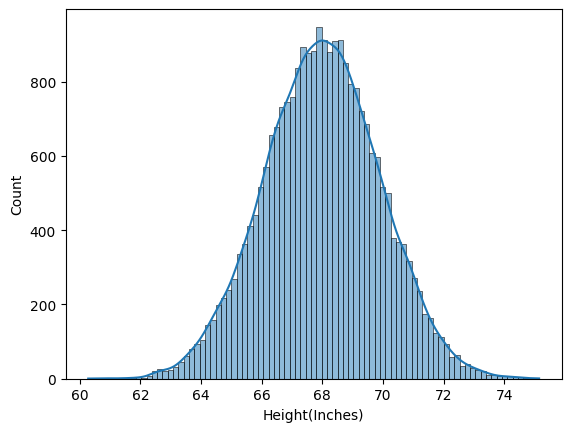

In [ ]:
import seaborn as sn
sn.histplot(df['Height(Inches)'], kde=True)

In [ ]:
mean=df['Height(Inches)'].mean()
mean

np.float64(67.99311359679999)

In [ ]:
std_deviation = df['Height(Inches)'].std()
std_deviation

1.901678771205604

In [ ]:
mean-2*std_deviation

np.float64(64.18975605438878)

In [ ]:
mean+2*std_deviation

np.float64(71.79647113921119)

In [ ]:
len(df[(df['Height(Inches)']<64.18975605438878)|(df['Height(Inches)']>71.79647113921119)])
# df[(df['Height(Inches)']<64.18975605438878)|(df['Height(Inches)']>71.79647113921119)]

1135

In [ ]:
df_no_outlier=df[(df['Height(Inches)']<71.79647113921119)&(df['Height(Inches)']>64.18975605438878)]
df_no_outlier
len(df_no_outlier)

23865

In [ ]:
df['z_score']=(df['Height(Inches)']-df['Height(Inches)'].mean())/df['Height(Inches)'].std()
df['z_score']


,z_score
Male,-1.162028
Female,1.852099
Male,0.739150
Female,0.117521
Male,-0.107959
...,...
Female,0.793529
Male,-1.811480
Female,-1.732450
Male,-0.243960


In [ ]:
df['z_score'] = (df['Height(Inches)'] - df['Height(Inches)'].mean()) / df['Height(Inches)'].std()
df['z_score']


,z_score
Male,-1.162028
Female,1.852099
Male,0.739150
Female,0.117521
Male,-0.107959
...,...
Female,0.793529
Male,-1.811480
Female,-1.732450
Male,-0.243960


In [ ]:
df[(df.z_score >2)| (df.z_score<-2)]

,Gender,Height(Inches),Weight(Pounds),z_score
Male,,63.48115,97.90191,-2.372621
Male,,71.80484,140.10150,2.004401
Female,,64.04535,106.71150,-2.075936
Female,,63.42577,123.09720,-2.401743
Female,,63.83624,127.19410,-2.185897
...,...,...,...,...
Female,,72.54953,134.51430,2.395997
Female,,72.35889,143.95470,2.295749
Female,,63.61791,115.74770,-2.300706
Female,,63.77967,111.49110,-2.215644


In [ ]:
df_no_outlier=df[(df.z_score <2)& (df.z_score>-2)]
df_no_outlier.shape

(23865, 4)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity ,cosine_distances

In [ ]:
cosine_similarity([[3,1]],[[6,2]])

array([[1.]])

In [ ]:
cosine_distances([[3,1]],[[6,2]])

array([[1.11022302e-16]])

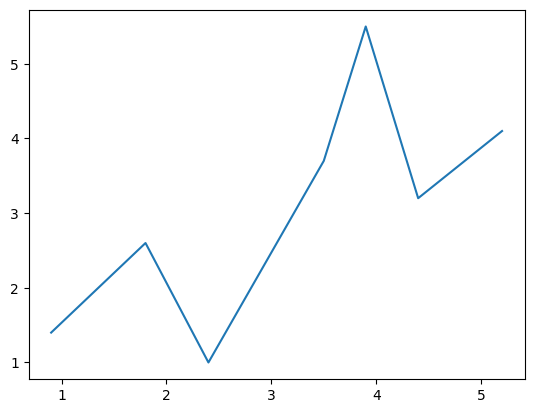

In [ ]:
import matplotlib.pyplot as plt
mouse_data={
    'weight':(0.9,1.8,2.4,3.5,3.9,4.4,5.2),
    'size':(1.4,2.6,1.0,3.7,5.5,3.2,4.1)
}
plt.plot(mouse_data['weight'],mouse_data['size'])


In [ ]:
data={'Name':"USMAN",'agr':'18'}
data['university']=12
data.update({'university':'university of punjab'})
data


{'Name': 'USMAN', 'agr': '18', 'university': 'university of punjab'}

In [ ]:
data.copy()

{'Name': 'USMAN', 'agr': '18', 'university': 'university of punjab'}

In [ ]:
data.pop('Name')

'USMAN'

In [ ]:
data

{'agr': '18', 'university': 'university of punjab'}

In [ ]:
del data['agr']


In [ ]:
age=18
if age >=18:
  print('adult')
else:
  print('minor')

adult


In [ ]:
countries=['Pakistan','china','india','america','indonesia']
countries

['Pakistan', 'china', 'india', 'america', 'indonesia']

In [ ]:
for country in  countries:
  print(country)

Pakistan
china
india
america
indonesia


In [ ]:
for i,country in enumerate(countries):
  print(i,country)


0 Pakistan
1 china
2 india
3 america
4 indonesia


In [ ]:
data={'Name': 'USMAN', 'agr': '18', 'university': 'university of punjab'}
for key,values in data.items():
  print(key,values)

Name USMAN
agr 18
university university of punjab


In [ ]:
def sum_values(a,b):
  return a+b
sum_values(1,4)

5

In [ ]:
import numpy as np
data=np.array([[1,2],[3,4],[5,6],[7,8]])
data


array([[1, 2],
       [3, 4],
       [5, 6],
       [7, 8]])

In [ ]:
import pandas as pd
df=pd.DataFrame(data,index=['row1','row2','row3','row4'],columns=['col1','col2'])
df

,col1,col2
row1,1,2
row2,3,4
row3,5,6
row4,7,8


In [ ]:
import pandas as pd
import numpy as np
import io
raw_data="""
"gender","race/ethnicity","parental level of education","lunch","test preparation course","math score","reading score","writing score"
"female","group B","bachelor's degree","standard","none","72","72","74"
"female","group C","some college","standard","completed","69","90","88"
"female","group B","master's degree","standard","none","90","95","93"
"male","group A","associate's degree","free/reduced","none","47","57","44"
"male","group C","some college","standard","none","76","78","75"
"female","group B","associate's degree","standard","none","71","83","78"
"female","group B","some college","standard","completed","88","95","92"
"male","group B","some college","free/reduced","none","40","43","39"
"male","group D","high school","free/reduced","completed","64","64","67"
"female","group B","high school","free/reduced","none","38","60","50"
"male","group C","associate's degree","standard","none","58","54","52"
"male","group D","associate's degree","standard","none","40","52","43"
"female","group B","high school","standard","none","65","81","73"
"male","group A","some college","standard","completed","78","72","70"
"female","group A","master's degree","standard","none","50","53","58"
"female","group C","some high school","standard","none","69","75","78"
"male","group C","high school","standard","none","88","89","86"
"female","group B","some high school","free/reduced","none","18","32","28"
"male","group C","master's degree","free/reduced","completed","46","42","46"
"female","group C","associate's degree","free/reduced","none","54","58","61"
"male","group D","high school","standard","none","66","69","63"
"female","group B","some college","free/reduced","completed","65","75","70"
"male","group D","some college","standard","none","44","54","53"
"female","group C","some high school","standard","none","69","73","73"
"male","group D","bachelor's degree","free/reduced","completed","74","71","80"
"male","group A","master's degree","free/reduced","none","73","74","72"
"male","group B","some college","standard","none","69","54","55"
"female","group C","bachelor's degree","standard","none","67","69","75"
"male","group C","high school","standard","none","70","70","65"
"female","group D","master's degree","standard","none","62","70","75"
"female","group D","some college","standard","none","69","74","74"
"female","group B","some college","standard","none","63","65","61"
"female","group E","master's degree","free/reduced","none","56","72","65"
"male","group D","some college","standard","none","40","42","38"
"male","group E","some college","standard","none","97","87","82"
"male","group E","associate's degree","standard","completed","81","81","79"
"female","group D","associate's degree","standard","none","74","81","83"
"female","group D","some high school","free/reduced","none","50","64","59"
"female","group D","associate's degree","free/reduced","completed","75","90","88"
"male","group B","associate's degree","free/reduced","none","57","56","57"
"male","group C","associate's degree","free/reduced","none","55","61","54"
"female","group C","associate's degree","standard","none","58","73","68"
"female","group B","associate's degree","standard","none","53","58","65"
"male","group B","some college","free/reduced","completed","59","65","66"
"female","group E","associate's degree","free/reduced","none","50","56","54"
"male","group B","associate's degree","standard","none","65","54","57"
"female","group A","associate's degree","standard","completed","55","65","62"
"female","group C","high school","standard","none","66","71","76"
"female","group D","associate's degree","free/reduced","completed","57","74","76"
"male","group C","high school","standard","completed","82","84","82"
"male","group E","some college","standard","none","53","55","48"
"male","group E","associate's degree","free/reduced","completed","77","69","68"
"male","group C","some college","standard","none","53","44","42"
"male","group D","high school","standard","none","88","78","75"
"female","group C","some high school","free/reduced","completed","71","84","87"
"female","group C","high school","free/reduced","none","33","41","43"
"female","group E","associate's degree","standard","completed","82","85","86"
"male","group D","associate's degree","standard","none","52","55","49"
"male","group D","some college","standard","completed","58","59","58"
"female","group C","some high school","free/reduced","none","0","17","10"
"male","group E","bachelor's degree","free/reduced","completed","79","74","72"
"male","group A","some high school","free/reduced","none","39","39","34"
"male","group A","associate's degree","free/reduced","none","62","61","55"
"female","group C","associate's degree","standard","none","69","80","71"
"female","group D","some high school","standard","none","59","58","59"
"male","group B","some high school","standard","none","67","64","61"
"male","group D","some high school","free/reduced","none","45","37","37"
"female","group C","some college","standard","none","60","72","74"
"male","group B","associate's degree","free/reduced","none","61","58","56"
"female","group C","associate's degree","standard","none","39","64","57"
"female","group D","some college","free/reduced","completed","58","63","73"
"male","group D","some college","standard","completed","63","55","63"
"female","group A","associate's degree","free/reduced","none","41","51","48"
"male","group C","some high school","free/reduced","none","61","57","56"
"male","group C","some high school","standard","none","49","49","41"
"male","group B","associate's degree","free/reduced","none","44","41","38"
"male","group E","some high school","standard","none","30","26","22"
"male","group A","bachelor's degree","standard","completed","80","78","81"
"female","group D","some high school","standard","completed","61","74","72"
"female","group E","master's degree","standard","none","62","68","68"
"female","group B","associate's degree","standard","none","47","49","50"
"male","group B","high school","free/reduced","none","49","45","45"
"male","group A","some college","free/reduced","completed","50","47","54"
"male","group E","associate's degree","standard","none","72","64","63"
"male","group D","high school","free/reduced","none","42","39","34"
"female","group C","some college","standard","none","73","80","82"
"female","group C","some college","free/reduced","none","76","83","88"
"female","group D","associate's degree","standard","none","71","71","74"
"female","group A","some college","standard","none","58","70","67"
"female","group D","some high school","standard","none","73","86","82"
"female","group C","bachelor's degree","standard","none","65","72","74"
"male","group C","high school","free/reduced","none","27","34","36"
"male","group C","high school","standard","none","71","79","71"
"male","group C","associate's degree","free/reduced","completed","43","45","50"
"female","group B","some college","standard","none","79","86","92"
"male","group C","associate's degree","free/reduced","completed","78","81","82"
"male","group B","some high school","standard","completed","65","66","62"
"female","group E","some college","standard","completed","63","72","70"
"female","group D","some college","free/reduced","none","58","67","62"
"female","group D","bachelor's degree","standard","none","65","67","62"
"male","group B","some college","standard","none","79","67","67"
"male","group D","bachelor's degree","standard","completed","68","74","74"
"female","group D","associate's degree","standard","none","85","91","89"
"male","group B","high school","standard","completed","60","44","47"
"male","group C","some college","standard","completed","98","86","90"
"female","group C","some college","standard","none","58","67","72"
"female","group D","master's degree","standard","none","87","100","100"
"male","group E","associate's degree","standard","completed","66","63","64"
"female","group B","associate's degree","free/reduced","none","52","76","70"
"female","group B","some high school","standard","none","70","64","72"
"female","group D","associate's degree","free/reduced","completed","77","89","98"
"male","group C","high school","standard","none","62","55","49"
"male","group A","associate's degree","standard","none","54","53","47"
"female","group D","some college","standard","none","51","58","54"
"female","group E","bachelor's degree","standard","completed","99","100","100"
"male","group C","high school","standard","none","84","77","74"
"female","group B","bachelor's degree","free/reduced","none","75","85","82"
"female","group D","bachelor's degree","standard","none","78","82","79"
"female","group D","some high school","standard","none","51","63","61"
"female","group C","some college","standard","none","55","69","65"
"female","group C","bachelor's degree","standard","completed","79","92","89"
"male","group B","associate's degree","standard","completed","91","89","92"
"female","group C","some college","standard","completed","88","93","93"
"male","group D","high school","free/reduced","none","63","57","56"
"male","group E","some college","standard","none","83","80","73"
"female","group B","high school","standard","none","87","95","86"
"male","group B","some high school","standard","none","72","68","67"
"male","group D","some college","standard","completed","65","77","74"
"male","group D","master's degree","standard","none","82","82","74"
"female","group A","bachelor's degree","standard","none","51","49","51"
"male","group D","master's degree","standard","none","89","84","82"
"male","group C","some high school","free/reduced","completed","53","37","40"
"male","group E","some college","free/reduced","completed","87","74","70"
"female","group C","some college","standard","completed","75","81","84"
"male","group D","bachelor's degree","free/reduced","completed","74","79","75"
"male","group C","bachelor's degree","standard","none","58","55","48"
"male","group B","some high school","standard","completed","51","54","41"
"male","group E","high school","standard","none","70","55","56"
"female","group C","associate's degree","standard","none","59","66","67"
"male","group D","some college","standard","completed","71","61","69"
"female","group D","some high school","standard","none","76","72","71"
"female","group C","some college","free/reduced","none","59","62","64"
"female","group E","some college","free/reduced","completed","42","55","54"
"male","group A","high school","standard","none","57","43","47"
"male","group D","some college","standard","none","88","73","78"
"female","group C","some college","free/reduced","none","22","39","33"
"male","group B","some high school","standard","none","88","84","75"
"male","group C","associate's degree","free/reduced","none","73","68","66"
"female","group D","bachelor's degree","standard","completed","68","75","81"
"male","group E","associate's degree","free/reduced","completed","100","100","93"
"male","group A","some high school","standard","completed","62","67","69"
"male","group A","bachelor's degree","standard","none","77","67","68"
"female","group B","associate's degree","standard","completed","59","70","66"
"male","group D","bachelor's degree","standard","none","54","49","47"
"male","group D","some high school","standard","none","62","67","61"
"female","group C","some college","standard","completed","70","89","88"
"female","group E","high school","free/reduced","completed","66","74","78"
"male","group B","some college","free/reduced","none","60","60","60"
"female","group B","associate's degree","standard","completed","61","86","87"
"male","group D","associate's degree","free/reduced","none","66","62","64"
"male","group B","associate's degree","free/reduced","completed","82","78","74"
"female","group E","some college","free/reduced","completed","75","88","85"
"male","group B","master's degree","free/reduced","none","49","53","52"
"male","group C","high school","standard","none","52","53","49"
"female","group E","master's degree","standard","none","81","92","91"
"female","group C","bachelor's degree","standard","completed","96","100","100"
"male","group C","high school","free/reduced","completed","53","51","51"
"female","group B","master's degree","free/reduced","completed","58","76","78"
"female","group B","high school","standard","completed","68","83","78"
"female","group C","some college","free/reduced","completed","67","75","70"
"male","group A","high school","standard","completed","72","73","74"
"male","group E","some high school","standard","none","94","88","78"
"female","group D","some college","standard","none","79","86","81"
"female","group C","associate's degree","standard","none","63","67","70"
"female","group C","bachelor's degree","free/reduced","completed","43","51","54"
"female","group C","master's degree","standard","completed","81","91","87"
"female","group B","high school","free/reduced","completed","46","54","58"
"female","group C","associate's degree","standard","completed","71","77","77"
"female","group B","master's degree","free/reduced","completed","52","70","62"
"female","group D","some high school","standard","completed","97","100","100"
"male","group C","master's degree","free/reduced","completed","62","68","75"
"female","group C","some college","free/reduced","none","46","64","66"
"female","group E","high school","standard","none","50","50","47"
"female","group D","associate's degree","standard","none","65","69","70"
"male","group C","some high school","free/reduced","completed","45","52","49"
"male","group C","associate's degree","free/reduced","completed","65","67","65"
"male","group E","high school","standard","none","80","76","65"
"male","group D","some high school","standard","completed","62","66","68"
"male","group B","some high school","free/reduced","none","48","52","45"
"female","group C","bachelor's degree","standard","none","77","88","87"
"female","group E","associate's degree","standard","none","66","65","69"
"male","group D","some college","standard","completed","76","83","79"
"female","group B","some high school","standard","none","62","64","66"
"male","group D","some college","standard","completed","77","62","62"
"female","group C","master's degree","standard","completed","69","84","85"
"male","group D","associate's degree","standard","none","61","55","52"
"male","group C","some high school","free/reduced","completed","59","69","65"
"male","group E","high school","free/reduced","none","55","56","51"
"female","group B","some college","free/reduced","none","45","53","55"
"female","group B","bachelor's degree","free/reduced","none","78","79","76"
"female","group C","associate's degree","standard","completed","67","84","86"
"female","group D","some college","free/reduced","none","65","81","77"
"male","group C","associate's degree","standard","none","69","77","69"
"female","group B","associate's degree","standard","none","57","69","68"
"male","group C","some college","standard","none","59","41","42"
"male","group D","some high school","standard","completed","74","71","78"
"male","group E","bachelor's degree","standard","none","82","62","62"
"male","group E","high school","standard","completed","81","80","76"
"female","group B","some college","free/reduced","none","74","81","76"
"female","group B","some college","free/reduced","none","58","61","66"
"male","group D","some high school","free/reduced","completed","80","79","79"
"male","group C","some college","free/reduced","none","35","28","27"
"female","group C","high school","free/reduced","none","42","62","60"
"male","group C","associate's degree","free/reduced","completed","60","51","56"
"male","group E","high school","standard","completed","87","91","81"
"male","group B","some high school","standard","completed","84","83","75"
"female","group E","associate's degree","free/reduced","completed","83","86","88"
"female","group C","high school","free/reduced","none","34","42","39"
"male","group B","high school","free/reduced","none","66","77","70"
"male","group B","some high school","standard","completed","61","56","56"
"female","group D","high school","standard","completed","56","68","74"
"male","group B","associate's degree","standard","none","87","85","73"
"female","group C","some high school","free/reduced","none","55","65","62"
"male","group D","some high school","standard","none","86","80","75"
"female","group B","associate's degree","standard","completed","52","66","73"
"female","group E","master's degree","free/reduced","none","45","56","54"
"female","group C","some college","standard","none","72","72","71"
"male","group D","high school","standard","none","57","50","54"
"male","group A","some high school","free/reduced","none","68","72","64"
"female","group C","some college","standard","completed","88","95","94"
"male","group D","some college","standard","none","76","64","66"
"male","group C","associate's degree","standard","none","46","43","42"
"female","group B","bachelor's degree","standard","none","67","86","83"
"male","group E","some high school","standard","none","92","87","78"
"male","group C","bachelor's degree","standard","completed","83","82","84"
"male","group D","associate's degree","standard","none","80","75","77"
"male","group D","bachelor's degree","free/reduced","none","63","66","67"
"female","group D","some high school","standard","completed","64","60","74"
"male","group B","some college","standard","none","54","52","51"
"male","group C","associate's degree","standard","none","84","80","80"
"male","group D","high school","free/reduced","completed","73","68","66"
"female","group E","bachelor's degree","standard","none","80","83","83"
"female","group D","high school","standard","none","56","52","55"
"male","group E","some college","standard","none","59","51","43"
"male","group D","some high school","standard","none","75","74","69"
"male","group C","associate's degree","standard","none","85","76","71"
"male","group E","associate's degree","standard","none","89","76","74"
"female","group B","high school","standard","completed","58","70","68"
"female","group B","high school","standard","none","65","64","62"
"male","group C","high school","standard","none","68","60","53"
"male","group A","some high school","standard","completed","47","49","49"
"female","group D","some college","free/reduced","none","71","83","83"
"female","group B","some high school","standard","completed","60","70","70"
"male","group D","master's degree","standard","none","80","80","72"
"male","group D","high school","standard","none","54","52","52"
"female","group E","some college","standard","none","62","73","70"
"female","group C","associate's degree","free/reduced","none","64","73","68"
"male","group C","associate's degree","standard","completed","78","77","77"
"female","group B","some college","standard","none","70","75","78"
"female","group C","master's degree","free/reduced","completed","65","81","81"
"female","group C","some high school","free/reduced","completed","64","79","77"
"male","group C","some college","standard","completed","79","79","78"
"female","group C","some high school","free/reduced","none","44","50","51"
"female","group E","high school","standard","none","99","93","90"
"male","group D","high school","standard","none","76","73","68"
"male","group D","some high school","free/reduced","none","59","42","41"
"female","group C","bachelor's degree","standard","none","63","75","81"
"female","group D","high school","standard","none","69","72","77"
"female","group D","associate's degree","standard","completed","88","92","95"
"female","group E","some college","free/reduced","none","71","76","70"
"male","group C","bachelor's degree","standard","none","69","63","61"
"male","group C","some college","standard","none","58","49","42"
"female","group D","associate's degree","free/reduced","none","47","53","58"
"female","group D","some college","standard","none","65","70","71"
"male","group B","some college","standard","completed","88","85","76"
"male","group C","bachelor's degree","standard","none","83","78","73"
"female","group C","some high school","standard","completed","85","92","93"
"female","group E","high school","standard","completed","59","63","75"
"female","group C","some high school","free/reduced","none","65","86","80"
"male","group B","bachelor's degree","free/reduced","none","73","56","57"
"male","group D","high school","standard","none","53","52","42"
"male","group D","high school","standard","none","45","48","46"
"female","group D","bachelor's degree","free/reduced","none","73","79","84"
"female","group D","some college","free/reduced","completed","70","78","78"
"female","group B","some high school","standard","none","37","46","46"
"male","group B","associate's degree","standard","completed","81","82","82"
"male","group E","associate's degree","standard","completed","97","82","88"
"female","group B","some high school","standard","none","67","89","82"
"male","group B","bachelor's degree","free/reduced","none","88","75","76"
"male","group E","some high school","standard","completed","77","76","77"
"male","group C","associate's degree","standard","none","76","70","68"
"male","group D","some high school","standard","none","86","73","70"
"male","group C","some high school","standard","completed","63","60","57"
"female","group E","bachelor's degree","standard","none","65","73","75"
"male","group D","high school","free/reduced","completed","78","77","80"
"male","group B","associate's degree","free/reduced","none","67","62","60"
"male","group A","some high school","standard","completed","46","41","43"
"male","group E","associate's degree","standard","completed","71","74","68"
"male","group C","high school","free/reduced","completed","40","46","50"
"male","group D","associate's degree","free/reduced","none","90","87","75"
"male","group A","some college","free/reduced","completed","81","78","81"
"male","group D","some high school","free/reduced","none","56","54","52"
"female","group C","associate's degree","standard","completed","67","84","81"
"male","group B","associate's degree","standard","none","80","76","64"
"female","group C","associate's degree","standard","completed","74","75","83"
"male","group A","some college","standard","none","69","67","69"
"male","group E","some college","standard","completed","99","87","81"
"male","group C","some high school","standard","none","51","52","44"
"female","group B","associate's degree","free/reduced","none","53","71","67"
"female","group D","high school","free/reduced","none","49","57","52"
"female","group B","associate's degree","standard","none","73","76","80"
"male","group B","bachelor's degree","standard","none","66","60","57"
"male","group D","bachelor's degree","standard","completed","67","61","68"
"female","group C","associate's degree","free/reduced","completed","68","67","69"
"female","group C","bachelor's degree","standard","completed","59","64","75"
"male","group C","high school","standard","none","71","66","65"
"female","group D","master's degree","standard","completed","77","82","91"
"male","group C","associate's degree","standard","none","83","72","78"
"male","group B","bachelor's degree","standard","none","63","71","69"
"female","group D","associate's degree","free/reduced","none","56","65","63"
"female","group C","high school","free/reduced","completed","67","79","84"
"female","group E","high school","standard","none","75","86","79"
"female","group C","some college","standard","none","71","81","80"
"female","group C","some high school","free/reduced","none","43","53","53"
"female","group C","high school","free/reduced","none","41","46","43"
"female","group C","some college","standard","none","82","90","94"
"male","group C","some college","standard","none","61","61","62"
"male","group A","some college","free/reduced","none","28","23","19"
"male","group C","associate's degree","standard","completed","82","75","77"
"female","group B","some high school","standard","none","41","55","51"
"male","group C","high school","standard","none","71","60","61"
"male","group C","associate's degree","standard","none","47","37","35"
"male","group E","associate's degree","standard","completed","62","56","53"
"male","group B","associate's degree","standard","none","90","78","81"
"female","group C","bachelor's degree","standard","none","83","93","95"
"female","group B","some college","free/reduced","none","61","68","66"
"male","group D","some high school","standard","completed","76","70","69"
"male","group C","associate's degree","standard","none","49","51","43"
"female","group B","some high school","free/reduced","none","24","38","27"
"female","group D","some high school","free/reduced","completed","35","55","60"
"male","group C","high school","free/reduced","none","58","61","52"
"female","group C","high school","standard","none","61","73","63"
"female","group B","high school","standard","completed","69","76","74"
"male","group D","associate's degree","standard","completed","67","72","67"
"male","group D","some college","standard","none","79","73","67"
"female","group C","high school","standard","none","72","80","75"
"male","group B","some college","standard","none","62","61","57"
"female","group C","bachelor's degree","standard","completed","77","94","95"
"male","group D","high school","free/reduced","none","75","74","66"
"male","group E","associate's degree","standard","none","87","74","76"
"female","group B","bachelor's degree","standard","none","52","65","69"
"male","group E","some college","standard","none","66","57","52"
"female","group C","some college","standard","completed","63","78","80"
"female","group C","associate's degree","standard","none","46","58","57"
"female","group C","some college","standard","none","59","71","70"
"female","group B","bachelor's degree","standard","none","61","72","70"
"male","group A","associate's degree","standard","none","63","61","61"
"female","group C","some college","free/reduced","completed","42","66","69"
"male","group D","some college","free/reduced","none","59","62","61"
"female","group D","some college","standard","none","80","90","89"
"female","group B","high school","standard","none","58","62","59"
"male","group B","some high school","standard","completed","85","84","78"
"female","group C","some college","standard","none","52","58","58"
"female","group D","some high school","free/reduced","none","27","34","32"
"male","group C","some college","standard","none","59","60","58"
"male","group A","bachelor's degree","free/reduced","completed","49","58","60"
"male","group C","high school","standard","completed","69","58","53"
"male","group C","bachelor's degree","free/reduced","none","61","66","61"
"female","group A","some high school","free/reduced","none","44","64","58"
"female","group D","some high school","standard","none","73","84","85"
"male","group E","some college","standard","none","84","77","71"
"female","group C","some college","free/reduced","completed","45","73","70"
"male","group D","some high school","standard","none","74","74","72"
"female","group D","some college","standard","completed","82","97","96"
"female","group D","bachelor's degree","standard","none","59","70","73"
"male","group E","associate's degree","free/reduced","none","46","43","41"
"female","group D","some high school","standard","none","80","90","82"
"female","group D","master's degree","free/reduced","completed","85","95","100"
"female","group A","some high school","standard","none","71","83","77"
"male","group A","bachelor's degree","standard","none","66","64","62"
"female","group B","associate's degree","standard","none","80","86","83"
"male","group C","associate's degree","standard","completed","87","100","95"
"male","group C","master's degree","free/reduced","none","79","81","71"
"female","group E","some high school","free/reduced","none","38","49","45"
"female","group A","some high school","free/reduced","none","38","43","43"
"female","group E","some college","standard","none","67","76","75"
"female","group E","bachelor's degree","standard","none","64","73","70"
"female","group C","associate's degree","free/reduced","none","57","78","67"
"female","group D","high school","standard","none","62","64","64"
"male","group D","master's degree","standard","none","73","70","75"
"male","group E","some high school","free/reduced","completed","73","67","59"
"female","group D","some college","standard","none","77","68","77"
"male","group E","some college","standard","none","76","67","67"
"male","group C","associate's degree","standard","completed","57","54","56"
"female","group C","some high school","standard","completed","65","74","77"
"male","group A","high school","free/reduced","none","48","45","41"
"female","group B","high school","free/reduced","none","50","67","63"
"female","group C","associate's degree","standard","none","85","89","95"
"male","group B","some high school","standard","none","74","63","57"
"male","group D","some high school","standard","none","60","59","54"
"female","group C","some high school","standard","completed","59","54","67"
"male","group A","some college","standard","none","53","43","43"
"female","group A","some college","free/reduced","none","49","65","55"
"female","group D","high school","standard","completed","88","99","100"
"female","group C","high school","standard","none","54","59","62"
"female","group C","some high school","standard","none","63","73","68"
"male","group B","associate's degree","standard","completed","65","65","63"
"female","group B","associate's degree","standard","none","82","80","77"
"female","group D","high school","free/reduced","completed","52","57","56"
"male","group D","associate's degree","standard","completed","87","84","85"
"female","group D","master's degree","standard","completed","70","71","74"
"male","group E","some college","standard","completed","84","83","78"
"male","group D","associate's degree","standard","none","71","66","60"
"male","group B","some high school","standard","completed","63","67","67"
"female","group C","bachelor's degree","free/reduced","completed","51","72","79"
"male","group E","high school","standard","none","84","73","69"
"male","group C","bachelor's degree","standard","completed","71","74","68"
"male","group C","associate's degree","standard","none","74","73","67"
"male","group D","some college","standard","none","68","59","62"
"male","group E","high school","free/reduced","completed","57","56","54"
"female","group C","associate's degree","free/reduced","completed","82","93","93"
"female","group D","high school","standard","completed","57","58","64"
"female","group D","master's degree","free/reduced","completed","47","58","67"
"female","group A","some high school","standard","completed","59","85","80"
"male","group B","some college","free/reduced","none","41","39","34"
"female","group C","some college","free/reduced","none","62","67","62"
"male","group C","bachelor's degree","standard","none","86","83","86"
"male","group C","some high school","free/reduced","none","69","71","65"
"male","group A","some high school","free/reduced","none","65","59","53"
"male","group C","some high school","free/reduced","none","68","63","54"
"male","group C","associate's degree","free/reduced","none","64","66","59"
"female","group C","high school","standard","none","61","72","70"
"male","group C","high school","standard","none","61","56","55"
"female","group A","some high school","free/reduced","none","47","59","50"
"male","group C","some high school","standard","none","73","66","66"
"male","group C","some college","free/reduced","completed","50","48","53"
"male","group D","associate's degree","standard","none","75","68","64"
"male","group D","associate's degree","free/reduced","none","75","66","73"
"male","group C","high school","standard","none","70","56","51"
"male","group D","some high school","standard","completed","89","88","82"
"female","group C","some college","standard","completed","67","81","79"
"female","group D","high school","standard","none","78","81","80"
"female","group A","some high school","free/reduced","none","59","73","69"
"female","group B","associate's degree","standard","none","73","83","76"
"male","group A","some high school","free/reduced","none","79","82","73"
"female","group C","some high school","standard","completed","67","74","77"
"male","group D","some college","free/reduced","none","69","66","60"
"male","group C","high school","standard","completed","86","81","80"
"male","group B","high school","standard","none","47","46","42"
"male","group B","associate's degree","standard","none","81","73","72"
"female","group C","some college","free/reduced","completed","64","85","85"
"female","group E","some college","standard","none","100","92","97"
"female","group C","associate's degree","free/reduced","none","65","77","74"
"male","group C","some college","free/reduced","none","65","58","49"
"female","group C","associate's degree","free/reduced","none","53","61","62"
"male","group C","bachelor's degree","free/reduced","none","37","56","47"
"female","group D","bachelor's degree","standard","none","79","89","89"
"male","group D","associate's degree","free/reduced","none","53","54","48"
"female","group E","bachelor's degree","standard","none","100","100","100"
"male","group B","high school","standard","completed","72","65","68"
"male","group C","bachelor's degree","free/reduced","none","53","58","55"
"male","group B","some college","free/reduced","none","54","54","45"
"female","group E","some college","standard","none","71","70","76"
"female","group C","some college","free/reduced","none","77","90","91"
"male","group A","bachelor's degree","standard","completed","75","58","62"
"female","group C","some college","standard","none","84","87","91"
"female","group D","associate's degree","free/reduced","none","26","31","38"
"male","group A","high school","free/reduced","completed","72","67","65"
"female","group A","high school","free/reduced","completed","77","88","85"
"male","group C","some college","standard","none","91","74","76"
"female","group C","associate's degree","standard","completed","83","85","90"
"female","group C","high school","standard","none","63","69","74"
"female","group C","associate's degree","standard","completed","68","86","84"
"female","group D","some high school","standard","none","59","67","61"
"female","group B","associate's degree","standard","completed","90","90","91"
"female","group D","bachelor's degree","standard","completed","71","76","83"
"male","group E","bachelor's degree","standard","completed","76","62","66"
"male","group D","associate's degree","standard","none","80","68","72"
"female","group D","master's degree","standard","none","55","64","70"
"male","group E","associate's degree","standard","none","76","71","67"
"male","group B","high school","standard","completed","73","71","68"
"female","group D","associate's degree","free/reduced","none","52","59","56"
"male","group C","some college","free/reduced","none","68","68","61"
"male","group A","high school","standard","none","59","52","46"
"female","group B","associate's degree","standard","none","49","52","54"
"male","group C","high school","standard","none","70","74","71"
"male","group D","some college","free/reduced","none","61","47","56"
"female","group C","associate's degree","free/reduced","none","60","75","74"
"male","group B","some high school","standard","completed","64","53","57"
"male","group A","associate's degree","free/reduced","completed","79","82","82"
"female","group A","associate's degree","free/reduced","none","65","85","76"
"female","group C","associate's degree","standard","none","64","64","70"
"female","group C","some college","standard","none","83","83","90"
"female","group C","bachelor's degree","standard","none","81","88","90"
"female","group B","high school","standard","none","54","64","68"
"male","group D","high school","standard","completed","68","64","66"
"female","group C","some college","standard","none","54","48","52"
"female","group D","some college","free/reduced","completed","59","78","76"
"female","group B","some high school","standard","none","66","69","68"
"male","group E","some college","standard","none","76","71","72"
"female","group D","master's degree","standard","none","74","79","82"
"female","group B","associate's degree","standard","completed","94","87","92"
"male","group C","some college","free/reduced","none","63","61","54"
"female","group E","associate's degree","standard","completed","95","89","92"
"female","group D","master's degree","free/reduced","none","40","59","54"
"female","group B","some high school","standard","none","82","82","80"
"male","group A","high school","standard","none","68","70","66"
"male","group B","bachelor's degree","free/reduced","none","55","59","54"
"male","group C","master's degree","standard","none","79","78","77"
"female","group C","bachelor's degree","standard","none","86","92","87"
"male","group D","some college","standard","none","76","71","73"
"male","group A","some high school","standard","none","64","50","43"
"male","group D","some high school","free/reduced","none","62","49","52"
"female","group B","some high school","standard","completed","54","61","62"
"female","group B","master's degree","free/reduced","completed","77","97","94"
"female","group C","some high school","standard","completed","76","87","85"
"female","group D","some college","standard","none","74","89","84"
"female","group E","some college","standard","completed","66","74","73"
"female","group D","some high school","standard","completed","66","78","78"
"female","group B","high school","free/reduced","completed","67","78","79"
"male","group D","some college","standard","none","71","49","52"
"female","group C","associate's degree","standard","none","91","86","84"
"male","group D","bachelor's degree","standard","none","69","58","57"
"male","group C","master's degree","free/reduced","none","54","59","50"
"male","group C","high school","standard","completed","53","52","49"
"male","group E","some college","standard","none","68","60","59"
"male","group C","some high school","free/reduced","completed","56","61","60"
"female","group C","high school","free/reduced","none","36","53","43"
"female","group D","bachelor's degree","free/reduced","none","29","41","47"
"female","group C","associate's degree","standard","none","62","74","70"
"female","group C","associate's degree","standard","completed","68","67","73"
"female","group C","some high school","standard","none","47","54","53"
"male","group E","associate's degree","standard","completed","62","61","58"
"female","group E","associate's degree","standard","completed","79","88","94"
"male","group B","high school","standard","completed","73","69","68"
"female","group C","bachelor's degree","free/reduced","completed","66","83","83"
"male","group C","associate's degree","standard","completed","51","60","58"
"female","group D","high school","standard","none","51","66","62"
"male","group E","bachelor's degree","standard","completed","85","66","71"
"male","group A","associate's degree","standard","completed","97","92","86"
"male","group C","high school","standard","completed","75","69","68"
"male","group D","associate's degree","free/reduced","completed","79","82","80"
"female","group C","associate's degree","standard","none","81","77","79"
"female","group D","associate's degree","standard","none","82","95","89"
"female","group D","master's degree","standard","none","64","63","66"
"male","group E","some high school","free/reduced","completed","78","83","80"
"female","group A","some high school","standard","completed","92","100","97"
"male","group C","high school","standard","completed","72","67","64"
"female","group C","high school","free/reduced","none","62","67","64"
"male","group C","master's degree","standard","none","79","72","69"
"male","group C","some high school","free/reduced","none","79","76","65"
"male","group B","bachelor's degree","free/reduced","completed","87","90","88"
"female","group B","associate's degree","standard","none","40","48","50"
"male","group D","some college","free/reduced","none","77","62","64"
"male","group E","associate's degree","standard","none","53","45","40"
"female","group C","some college","free/reduced","none","32","39","33"
"female","group C","associate's degree","standard","completed","55","72","79"
"male","group C","master's degree","free/reduced","none","61","67","66"
"female","group B","associate's degree","free/reduced","none","53","70","70"
"male","group D","some high school","standard","none","73","66","62"
"female","group D","some college","standard","completed","74","75","79"
"female","group C","some college","standard","none","63","74","74"
"male","group C","bachelor's degree","standard","completed","96","90","92"
"female","group D","some college","free/reduced","completed","63","80","80"
"male","group B","bachelor's degree","free/reduced","none","48","51","46"
"male","group B","associate's degree","standard","none","48","43","45"
"female","group E","bachelor's degree","free/reduced","completed","92","100","100"
"female","group D","master's degree","free/reduced","completed","61","71","78"
"male","group B","high school","free/reduced","none","63","48","47"
"male","group D","bachelor's degree","free/reduced","none","68","68","67"
"male","group B","some college","standard","completed","71","75","70"
"male","group A","bachelor's degree","standard","none","91","96","92"
"female","group C","some college","standard","none","53","62","56"
"female","group C","high school","free/reduced","completed","50","66","64"
"female","group E","high school","standard","none","74","81","71"
"male","group A","associate's degree","free/reduced","completed","40","55","53"
"male","group A","some college","standard","completed","61","51","52"
"female","group B","high school","standard","none","81","91","89"
"female","group B","some college","free/reduced","completed","48","56","58"
"female","group D","master's degree","standard","none","53","61","68"
"female","group D","some high school","standard","none","81","97","96"
"female","group E","some high school","standard","none","77","79","80"
"female","group D","bachelor's degree","free/reduced","none","63","73","78"
"female","group D","associate's degree","standard","completed","73","75","80"
"female","group D","some college","standard","none","69","77","77"
"female","group C","associate's degree","standard","none","65","76","76"
"female","group A","high school","standard","none","55","73","73"
"female","group C","bachelor's degree","free/reduced","none","44","63","62"
"female","group C","some college","standard","none","54","64","65"
"female","group A","some high school","standard","none","48","66","65"
"male","group C","some college","free/reduced","none","58","57","54"
"male","group A","some high school","standard","none","71","62","50"
"male","group E","bachelor's degree","standard","none","68","68","64"
"female","group E","high school","standard","none","74","76","73"
"female","group C","bachelor's degree","standard","completed","92","100","99"
"female","group C","bachelor's degree","standard","completed","56","79","72"
"male","group B","high school","free/reduced","none","30","24","15"
"male","group A","some high school","standard","none","53","54","48"
"female","group D","high school","standard","none","69","77","73"
"female","group D","some high school","standard","none","65","82","81"
"female","group D","master's degree","standard","none","54","60","63"
"female","group C","high school","standard","none","29","29","30"
"female","group E","some college","standard","none","76","78","80"
"male","group D","high school","free/reduced","none","60","57","51"
"male","group D","master's degree","free/reduced","completed","84","89","90"
"male","group C","some high school","standard","none","75","72","62"
"female","group C","associate's degree","standard","none","85","84","82"
"female","group C","master's degree","free/reduced","none","40","58","54"
"female","group E","some college","standard","none","61","64","62"
"female","group B","associate's degree","standard","none","58","63","65"
"male","group D","some college","free/reduced","completed","69","60","63"
"female","group C","some college","standard","none","58","59","66"
"male","group C","bachelor's degree","standard","completed","94","90","91"
"female","group C","associate's degree","standard","none","65","77","74"
"female","group A","associate's degree","standard","none","82","93","93"
"female","group C","high school","standard","none","60","68","72"
"female","group E","bachelor's degree","standard","none","37","45","38"
"male","group D","bachelor's degree","standard","none","88","78","83"
"male","group D","master's degree","standard","none","95","81","84"
"male","group C","associate's degree","free/reduced","completed","65","73","68"
"female","group C","high school","free/reduced","none","35","61","54"
"male","group B","bachelor's degree","free/reduced","none","62","63","56"
"male","group C","high school","free/reduced","completed","58","51","52"
"male","group A","some college","standard","completed","100","96","86"
"female","group E","bachelor's degree","free/reduced","none","61","58","62"
"male","group D","some college","standard","completed","100","97","99"
"male","group B","associate's degree","free/reduced","completed","69","70","63"
"male","group D","associate's degree","standard","none","61","48","46"
"male","group D","some college","free/reduced","none","49","57","46"
"female","group C","some high school","standard","completed","44","51","55"
"male","group D","some college","standard","none","67","64","70"
"male","group B","high school","standard","none","79","60","65"
"female","group B","bachelor's degree","standard","completed","66","74","81"
"female","group C","high school","standard","none","75","88","85"
"male","group D","some high school","standard","none","84","84","80"
"male","group A","high school","standard","none","71","74","64"
"female","group B","high school","free/reduced","completed","67","80","81"
"female","group D","some high school","standard","completed","80","92","88"
"male","group E","some college","standard","none","86","76","74"
"female","group D","associate's degree","standard","none","76","74","73"
"male","group D","high school","standard","none","41","52","51"
"female","group D","associate's degree","free/reduced","completed","74","88","90"
"female","group B","some high school","free/reduced","none","72","81","79"
"female","group E","high school","standard","completed","74","79","80"
"male","group B","high school","standard","none","70","65","60"
"female","group B","bachelor's degree","standard","completed","65","81","81"
"female","group D","associate's degree","standard","none","59","70","65"
"female","group E","high school","free/reduced","none","64","62","68"
"female","group B","high school","standard","none","50","53","55"
"female","group D","some college","standard","completed","69","79","81"
"male","group C","some high school","free/reduced","completed","51","56","53"
"female","group A","high school","standard","completed","68","80","76"
"female","group D","some college","standard","completed","85","86","98"
"female","group A","associate's degree","standard","completed","65","70","74"
"female","group B","some high school","standard","none","73","79","79"
"female","group B","some college","standard","none","62","67","67"
"male","group C","associate's degree","free/reduced","none","77","67","64"
"male","group D","some high school","standard","none","69","66","61"
"female","group D","associate's degree","free/reduced","none","43","60","58"
"male","group D","associate's degree","standard","none","90","87","85"
"male","group C","some college","free/reduced","none","74","77","73"
"male","group C","some high school","standard","none","73","66","63"
"female","group D","some college","free/reduced","none","55","71","69"
"female","group C","high school","standard","none","65","69","67"
"male","group D","associate's degree","standard","none","80","63","63"
"female","group C","some high school","free/reduced","completed","50","60","60"
"female","group C","some college","free/reduced","completed","63","73","71"
"female","group B","bachelor's degree","free/reduced","none","77","85","87"
"male","group C","some college","standard","none","73","74","61"
"male","group D","associate's degree","standard","completed","81","72","77"
"female","group C","high school","free/reduced","none","66","76","68"
"male","group D","associate's degree","free/reduced","none","52","57","50"
"female","group C","some college","standard","none","69","78","76"
"female","group C","associate's degree","standard","completed","65","84","84"
"female","group D","high school","standard","completed","69","77","78"
"female","group B","some college","standard","completed","50","64","66"
"female","group E","some college","standard","completed","73","78","76"
"female","group C","some high school","standard","completed","70","82","76"
"male","group D","associate's degree","free/reduced","none","81","75","78"
"male","group D","some college","free/reduced","none","63","61","60"
"female","group D","high school","standard","none","67","72","74"
"male","group B","high school","standard","none","60","68","60"
"male","group B","high school","standard","none","62","55","54"
"female","group C","some high school","free/reduced","completed","29","40","44"
"male","group B","some college","standard","completed","62","66","68"
"female","group E","master's degree","standard","completed","94","99","100"
"male","group E","some college","standard","completed","85","75","68"
"male","group D","associate's degree","free/reduced","none","77","78","73"
"male","group A","high school","free/reduced","none","53","58","44"
"male","group E","some college","free/reduced","none","93","90","83"
"female","group C","associate's degree","standard","none","49","53","53"
"female","group E","associate's degree","free/reduced","none","73","76","78"
"female","group C","bachelor's degree","free/reduced","completed","66","74","81"
"female","group D","associate's degree","standard","none","77","77","73"
"female","group C","some high school","standard","none","49","63","56"
"female","group D","some college","free/reduced","none","79","89","86"
"female","group C","associate's degree","standard","completed","75","82","90"
"female","group A","bachelor's degree","standard","none","59","72","70"
"female","group D","associate's degree","standard","completed","57","78","79"
"male","group C","high school","free/reduced","none","66","66","59"
"female","group E","bachelor's degree","standard","completed","79","81","82"
"female","group B","some high school","standard","none","57","67","72"
"male","group A","bachelor's degree","standard","completed","87","84","87"
"female","group D","some college","standard","none","63","64","67"
"female","group B","some high school","free/reduced","completed","59","63","64"
"male","group A","bachelor's degree","free/reduced","none","62","72","65"
"male","group D","high school","standard","none","46","34","36"
"male","group C","some college","standard","none","66","59","52"
"male","group D","high school","standard","none","89","87","79"
"female","group D","associate's degree","free/reduced","completed","42","61","58"
"male","group C","some college","standard","completed","93","84","90"
"female","group E","some high school","standard","completed","80","85","85"
"female","group D","some college","standard","none","98","100","99"
"male","group D","master's degree","standard","none","81","81","84"
"female","group B","some high school","standard","completed","60","70","74"
"female","group B","associate's degree","free/reduced","completed","76","94","87"
"male","group C","associate's degree","standard","completed","73","78","72"
"female","group C","associate's degree","standard","completed","96","96","99"
"female","group C","high school","standard","none","76","76","74"
"male","group E","associate's degree","free/reduced","completed","91","73","80"
"female","group C","some college","free/reduced","none","62","72","70"
"male","group D","some high school","free/reduced","completed","55","59","59"
"female","group B","some high school","free/reduced","completed","74","90","88"
"male","group C","high school","standard","none","50","48","42"
"male","group B","some college","standard","none","47","43","41"
"male","group E","some college","standard","completed","81","74","71"
"female","group E","associate's degree","standard","completed","65","75","77"
"male","group E","some high school","standard","completed","68","51","57"
"female","group D","high school","free/reduced","none","73","92","84"
"male","group C","some college","standard","none","53","39","37"
"female","group B","associate's degree","free/reduced","completed","68","77","80"
"male","group A","some high school","free/reduced","none","55","46","43"
"female","group C","some college","standard","completed","87","89","94"
"male","group D","some high school","standard","none","55","47","44"
"female","group E","some college","free/reduced","none","53","58","57"
"male","group C","master's degree","standard","none","67","57","59"
"male","group C","associate's degree","standard","none","92","79","84"
"female","group B","some college","free/reduced","completed","53","66","73"
"male","group D","associate's degree","standard","none","81","71","73"
"male","group C","high school","free/reduced","none","61","60","55"
"male","group D","bachelor's degree","standard","none","80","73","72"
"female","group A","associate's degree","free/reduced","none","37","57","56"
"female","group C","high school","standard","none","81","84","82"
"female","group C","associate's degree","standard","completed","59","73","72"
"male","group B","some college","free/reduced","none","55","55","47"
"male","group D","associate's degree","standard","none","72","79","74"
"male","group D","high school","standard","none","69","75","71"
"male","group C","some college","standard","none","69","64","68"
"female","group C","bachelor's degree","free/reduced","none","50","60","59"
"male","group B","some college","standard","completed","87","84","86"
"male","group D","some high school","standard","completed","71","69","68"
"male","group E","some college","standard","none","68","72","65"
"male","group C","master's degree","free/reduced","completed","79","77","75"
"female","group C","some high school","standard","completed","77","90","85"
"male","group C","associate's degree","free/reduced","none","58","55","53"
"female","group E","associate's degree","standard","none","84","95","92"
"male","group D","some college","standard","none","55","58","52"
"male","group E","bachelor's degree","free/reduced","completed","70","68","72"
"female","group D","some college","free/reduced","completed","52","59","65"
"male","group B","some college","standard","completed","69","77","77"
"female","group C","high school","free/reduced","none","53","72","64"
"female","group D","some high school","standard","none","48","58","54"
"male","group D","some high school","standard","completed","78","81","86"
"female","group B","high school","standard","none","62","62","63"
"male","group D","some college","standard","none","60","63","59"
"female","group B","high school","standard","none","74","72","72"
"female","group C","high school","standard","completed","58","75","77"
"male","group B","high school","standard","completed","76","62","60"
"female","group D","some high school","standard","none","68","71","75"
"male","group A","some college","free/reduced","none","58","60","57"
"male","group B","high school","standard","none","52","48","49"
"male","group D","bachelor's degree","standard","none","75","73","74"
"female","group B","some high school","free/reduced","completed","52","67","72"
"female","group C","bachelor's degree","free/reduced","none","62","78","79"
"male","group B","some college","standard","none","66","65","60"
"female","group B","some high school","free/reduced","none","49","58","55"
"female","group B","high school","standard","none","66","72","70"
"female","group C","some college","free/reduced","none","35","44","43"
"female","group A","some college","standard","completed","72","79","82"
"male","group E","associate's degree","standard","completed","94","85","82"
"female","group D","associate's degree","free/reduced","none","46","56","57"
"female","group B","master's degree","standard","none","77","90","84"
"female","group B","high school","free/reduced","completed","76","85","82"
"female","group C","associate's degree","standard","completed","52","59","62"
"male","group C","bachelor's degree","standard","completed","91","81","79"
"female","group B","some high school","standard","completed","32","51","44"
"female","group E","some high school","free/reduced","none","72","79","77"
"female","group B","some college","standard","none","19","38","32"
"male","group C","associate's degree","free/reduced","none","68","65","61"
"female","group C","master's degree","free/reduced","none","52","65","61"
"female","group B","high school","standard","none","48","62","60"
"female","group D","some college","free/reduced","none","60","66","70"
"male","group D","high school","free/reduced","none","66","74","69"
"male","group E","some high school","standard","completed","89","84","77"
"female","group B","high school","standard","none","42","52","51"
"female","group E","associate's degree","free/reduced","completed","57","68","73"
"male","group D","high school","standard","none","70","70","70"
"female","group E","associate's degree","free/reduced","none","70","84","81"
"male","group E","some college","standard","none","69","60","54"
"female","group C","associate's degree","standard","none","52","55","57"
"male","group C","some high school","standard","completed","67","73","68"
"male","group C","some high school","standard","completed","76","80","73"
"female","group E","associate's degree","standard","none","87","94","95"
"female","group B","some college","standard","none","82","85","87"
"female","group C","some college","standard","none","73","76","78"
"male","group A","some college","free/reduced","none","75","81","74"
"female","group D","some college","free/reduced","none","64","74","75"
"female","group E","high school","free/reduced","none","41","45","40"
"male","group C","high school","standard","none","90","75","69"
"male","group B","bachelor's degree","standard","none","59","54","51"
"male","group A","some high school","standard","none","51","31","36"
"male","group A","high school","free/reduced","none","45","47","49"
"female","group C","master's degree","standard","completed","54","64","67"
"male","group E","some high school","standard","completed","87","84","76"
"female","group C","high school","standard","none","72","80","83"
"male","group B","some high school","standard","completed","94","86","87"
"female","group A","bachelor's degree","standard","none","45","59","64"
"male","group D","bachelor's degree","free/reduced","completed","61","70","76"
"female","group B","high school","free/reduced","none","60","72","68"
"female","group C","some high school","standard","none","77","91","88"
"female","group A","some high school","standard","completed","85","90","92"
"female","group D","bachelor's degree","free/reduced","none","78","90","93"
"male","group E","some college","free/reduced","completed","49","52","51"
"female","group B","high school","free/reduced","none","71","87","82"
"female","group C","some high school","free/reduced","none","48","58","52"
"male","group C","high school","standard","none","62","67","58"
"female","group C","associate's degree","free/reduced","completed","56","68","70"
"female","group C","some high school","standard","none","65","69","76"
"female","group D","some high school","free/reduced","completed","69","86","81"
"male","group B","some high school","standard","none","68","54","53"
"female","group A","some college","free/reduced","none","61","60","57"
"female","group C","bachelor's degree","free/reduced","completed","74","86","89"
"male","group A","bachelor's degree","standard","none","64","60","58"
"female","group B","high school","standard","completed","77","82","89"
"male","group B","some college","standard","none","58","50","45"
"female","group C","high school","standard","completed","60","64","74"
"male","group E","high school","standard","none","73","64","57"
"female","group A","high school","standard","completed","75","82","79"
"male","group B","associate's degree","free/reduced","completed","58","57","53"
"female","group C","associate's degree","standard","none","66","77","73"
"female","group D","high school","free/reduced","none","39","52","46"
"male","group C","some high school","standard","none","64","58","51"
"female","group B","high school","free/reduced","completed","23","44","36"
"male","group B","some college","free/reduced","completed","74","77","76"
"female","group D","some high school","free/reduced","completed","40","65","64"
"male","group E","master's degree","standard","none","90","85","84"
"male","group C","master's degree","standard","completed","91","85","85"
"male","group D","high school","standard","none","64","54","50"
"female","group C","high school","standard","none","59","72","68"
"male","group D","associate's degree","standard","none","80","75","69"
"male","group C","master's degree","standard","none","71","67","67"
"female","group A","high school","standard","none","61","68","63"
"female","group E","some college","standard","none","87","85","93"
"male","group E","some high school","standard","none","82","67","61"
"male","group C","some high school","standard","none","62","64","55"
"female","group B","bachelor's degree","standard","none","97","97","96"
"male","group B","some college","free/reduced","none","75","68","65"
"female","group C","bachelor's degree","standard","none","65","79","81"
"male","group B","high school","standard","completed","52","49","46"
"male","group C","associate's degree","free/reduced","none","87","73","72"
"female","group C","associate's degree","standard","none","53","62","53"
"female","group E","master's degree","free/reduced","none","81","86","87"
"male","group D","bachelor's degree","free/reduced","completed","39","42","38"
"female","group C","some college","standard","completed","71","71","80"
"male","group C","associate's degree","standard","none","97","93","91"
"male","group D","some college","standard","completed","82","82","88"
"male","group C","high school","free/reduced","none","59","53","52"
"male","group B","associate's degree","standard","none","61","42","41"
"male","group E","associate's degree","free/reduced","completed","78","74","72"
"male","group C","associate's degree","free/reduced","none","49","51","51"
"male","group B","high school","standard","none","59","58","47"
"female","group C","some college","standard","completed","70","72","76"
"male","group B","associate's degree","standard","completed","82","84","78"
"male","group E","associate's degree","free/reduced","none","90","90","82"
"female","group C","bachelor's degree","free/reduced","none","43","62","61"
"male","group C","some college","free/reduced","none","80","64","66"
"male","group D","some college","standard","none","81","82","84"
"male","group C","some high school","standard","none","57","61","54"
"female","group D","some high school","standard","none","59","72","80"
"female","group D","associate's degree","standard","none","64","76","74"
"male","group C","bachelor's degree","standard","completed","63","64","66"
"female","group E","bachelor's degree","standard","completed","71","70","70"
"female","group B","high school","free/reduced","none","64","73","71"
"male","group D","bachelor's degree","free/reduced","none","55","46","44"
"female","group E","associate's degree","standard","none","51","51","54"
"female","group C","associate's degree","standard","completed","62","76","80"
"female","group E","associate's degree","standard","completed","93","100","95"
"male","group C","high school","free/reduced","none","54","72","59"
"female","group D","some college","free/reduced","none","69","65","74"
"male","group D","high school","free/reduced","none","44","51","48"
"female","group E","some college","standard","completed","86","85","91"
"female","group E","associate's degree","standard","none","85","92","85"
"female","group A","master's degree","free/reduced","none","50","67","73"
"male","group D","some high school","standard","completed","88","74","75"
"female","group E","associate's degree","standard","none","59","62","69"
"female","group E","some high school","free/reduced","none","32","34","38"
"male","group B","high school","free/reduced","none","36","29","27"
"female","group B","some high school","free/reduced","completed","63","78","79"
"male","group D","associate's degree","standard","completed","67","54","63"
"female","group D","some high school","standard","completed","65","78","82"
"male","group D","master's degree","standard","none","85","84","89"
"female","group C","master's degree","standard","none","73","78","74"
"female","group A","high school","free/reduced","completed","34","48","41"
"female","group D","bachelor's degree","free/reduced","completed","93","100","100"
"female","group D","some high school","free/reduced","none","67","84","84"
"male","group D","some college","standard","none","88","77","77"
"male","group B","high school","standard","none","57","48","51"
"female","group D","some college","standard","completed","79","84","91"
"female","group C","bachelor's degree","free/reduced","none","67","75","72"
"male","group E","bachelor's degree","standard","completed","70","64","70"
"male","group D","bachelor's degree","free/reduced","none","50","42","48"
"female","group A","some college","standard","none","69","84","82"
"female","group C","bachelor's degree","standard","completed","52","61","66"
"female","group C","bachelor's degree","free/reduced","completed","47","62","66"
"female","group B","associate's degree","free/reduced","none","46","61","55"
"female","group E","some college","standard","none","68","70","66"
"male","group E","bachelor's degree","standard","completed","100","100","100"
"female","group C","high school","standard","none","44","61","52"
"female","group C","associate's degree","standard","completed","57","77","80"
"male","group B","some college","standard","completed","91","96","91"
"male","group D","high school","free/reduced","none","69","70","67"
"female","group C","high school","free/reduced","none","35","53","46"
"male","group D","high school","standard","none","72","66","66"
"female","group B","associate's degree","free/reduced","none","54","65","65"
"male","group D","high school","free/reduced","none","74","70","69"
"male","group E","some high school","standard","completed","74","64","60"
"male","group E","associate's degree","free/reduced","none","64","56","52"
"female","group D","high school","free/reduced","completed","65","61","71"
"male","group E","associate's degree","free/reduced","completed","46","43","44"
"female","group C","some high school","free/reduced","none","48","56","51"
"male","group C","some college","free/reduced","completed","67","74","70"
"male","group D","some college","free/reduced","none","62","57","62"
"male","group D","associate's degree","free/reduced","completed","61","71","73"
"male","group C","bachelor's degree","free/reduced","completed","70","75","74"
"male","group C","associate's degree","standard","completed","98","87","90"
"male","group D","some college","free/reduced","none","70","63","58"
"male","group A","associate's degree","standard","none","67","57","53"
"female","group E","high school","free/reduced","none","57","58","57"
"male","group D","some college","standard","completed","85","81","85"
"male","group D","some high school","standard","completed","77","68","69"
"male","group C","master's degree","free/reduced","completed","72","66","72"
"female","group D","master's degree","standard","none","78","91","96"
"male","group C","high school","standard","none","81","66","64"
"male","group A","some high school","free/reduced","completed","61","62","61"
"female","group B","high school","standard","none","58","68","61"
"female","group C","associate's degree","standard","none","54","61","58"
"male","group B","high school","standard","none","82","82","80"
"female","group D","some college","free/reduced","none","49","58","60"
"male","group B","some high school","free/reduced","completed","49","50","52"
"female","group E","high school","free/reduced","completed","57","75","73"
"male","group E","high school","standard","none","94","73","71"
"female","group D","some college","standard","completed","75","77","83"
"female","group E","some high school","free/reduced","none","74","74","72"
"male","group C","high school","standard","completed","58","52","54"
"female","group C","some college","standard","none","62","69","69"
"male","group E","associate's degree","standard","none","72","57","62"
"male","group C","some college","standard","none","84","87","81"
"female","group D","master's degree","standard","none","92","100","100"
"female","group D","high school","standard","none","45","63","59"
"male","group C","high school","standard","none","75","81","71"
"female","group A","some college","standard","none","56","58","64"
"female","group D","some high school","free/reduced","none","48","54","53"
"female","group E","associate's degree","standard","none","100","100","100"
"female","group C","some high school","free/reduced","completed","65","76","75"
"male","group D","some college","standard","none","72","57","58"
"female","group D","some college","standard","none","62","70","72"
"male","group A","some high school","standard","completed","66","68","64"
"male","group C","some college","standard","none","63","63","60"
"female","group E","associate's degree","standard","none","68","76","67"
"female","group B","bachelor's degree","standard","none","75","84","80"
"female","group D","bachelor's degree","standard","none","89","100","100"
"male","group C","some high school","standard","completed","78","72","69"
"female","group A","high school","free/reduced","completed","53","50","60"
"female","group D","some college","free/reduced","none","49","65","61"
"female","group A","some college","standard","none","54","63","67"
"female","group C","some college","standard","completed","64","82","77"
"male","group B","some college","free/reduced","completed","60","62","60"
"male","group C","associate's degree","standard","none","62","65","58"
"male","group D","high school","standard","completed","55","41","48"
"female","group C","associate's degree","standard","none","91","95","94"
"female","group B","high school","free/reduced","none","8","24","23"
"male","group D","some high school","standard","none","81","78","78"
"male","group B","some high school","standard","completed","79","85","86"
"female","group A","some college","standard","completed","78","87","91"
"female","group C","some high school","standard","none","74","75","82"
"male","group A","high school","standard","none","57","51","54"
"female","group C","associate's degree","standard","none","40","59","51"
"male","group E","some high school","standard","completed","81","75","76"
"female","group A","some high school","free/reduced","none","44","45","45"
"female","group D","some college","free/reduced","completed","67","86","83"
"male","group E","high school","free/reduced","completed","86","81","75"
"female","group B","some high school","standard","completed","65","82","78"
"female","group D","associate's degree","free/reduced","none","55","76","76"
"female","group D","bachelor's degree","free/reduced","none","62","72","74"
"male","group A","high school","standard","none","63","63","62"
"female","group E","master's degree","standard","completed","88","99","95"
"male","group C","high school","free/reduced","none","62","55","55"
"female","group C","high school","free/reduced","completed","59","71","65"
"female","group D","some college","standard","completed","68","78","77"
"female","group D","some college","free/reduced","none","77","86","86"
"""
df = pd.read_csv(io.StringIO(raw_data))
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
language_score = 80
df['language score'] = language_score
df['language score']=np.random.randint(1,100, size=1000)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,language score
0,female,group B,bachelor's degree,standard,none,72,72,74,27
1,female,group C,some college,standard,completed,69,90,88,3
2,female,group B,master's degree,standard,none,90,95,93,43
3,male,group A,associate's degree,free/reduced,none,47,57,44,75
4,male,group C,some college,standard,none,76,78,75,25
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,32
996,male,group C,high school,free/reduced,none,62,55,55,30
997,female,group C,high school,free/reduced,completed,59,71,65,61
998,female,group D,some college,standard,completed,68,78,77,36


In [ ]:
score1=np.random.randint(1,100, size=1000)
score2=np.random.randint(1,100, size=1000)

In [ ]:
df[['score1','score2']]=np.column_stack([score1,score2])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,language score,score1,score2
0,female,group B,bachelor's degree,standard,none,72,72,74,27,86,32
1,female,group C,some college,standard,completed,69,90,88,3,80,48
2,female,group B,master's degree,standard,none,90,95,93,43,21,83
3,male,group A,associate's degree,free/reduced,none,47,57,44,75,50,77
4,male,group C,some college,standard,none,76,78,75,25,55,1
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,32,95,18
996,male,group C,high school,free/reduced,none,62,55,55,30,32,49
997,female,group C,high school,free/reduced,completed,59,71,65,61,59,18
998,female,group D,some college,standard,completed,68,78,77,36,98,57


In [ ]:
# df.insert(1,'name' ,score1)
# df.insert(4,'test' ,score2)
# df=df.drop(columns='name')
# df=df.drop(columns='test')
df['parental level of education'].value_counts()
df


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,language score,score1,score2
0,female,group B,bachelor's degree,standard,none,72,72,74,27,86,32
1,female,group C,some college,standard,completed,69,90,88,3,80,48
2,female,group B,master's degree,standard,none,90,95,93,43,21,83
3,male,group A,associate's degree,free/reduced,none,47,57,44,75,50,77
4,male,group C,some college,standard,none,76,78,75,25,55,1
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,32,95,18
996,male,group C,high school,free/reduced,none,62,55,55,30,32,49
997,female,group C,high school,free/reduced,completed,59,71,65,61,59,18
998,female,group D,some college,standard,completed,68,78,77,36,98,57


In [ ]:
df=df.rename(columns={'gender':'Gender','race/ethnicity':'Race/Ethnicity','parental level of education':'Parental Education','lunch':'Lunch','test preparation course':'Test Preparation','math score':'Maths Score','reading score':'Reading Score','writing score':'Writing Score','language score':'Language Score','score1':'Score 1','score2':'Score 2'})
df['Gender']=df.Gender.str.title()
df['Race/Ethnicity']=df['Race/Ethnicity'].str.title()
df['Parental Education']=df['Parental Education'].str.title()
df['Lunch']=df['Lunch'].str.title()
df



,Gender,Race/Ethnicity,Parental Education,Lunch,Test Preparation,Maths Score,Reading Score,Writing Score,Language Score,Score 1,Score 2
0,Female,Group B,Bachelor'S Degree,Standard,none,72,72,74,27,86,32
1,Female,Group C,Some College,Standard,completed,69,90,88,3,80,48
2,Female,Group B,Master'S Degree,Standard,none,90,95,93,43,21,83
3,Male,Group A,Associate'S Degree,Free/Reduced,none,47,57,44,75,50,77
4,Male,Group C,Some College,Standard,none,76,78,75,25,55,1
...,...,...,...,...,...,...,...,...,...,...,...
995,Female,Group E,Master'S Degree,Standard,completed,88,99,95,32,95,18
996,Male,Group C,High School,Free/Reduced,none,62,55,55,30,32,49
997,Female,Group C,High School,Free/Reduced,completed,59,71,65,61,59,18
998,Female,Group D,Some College,Standard,completed,68,78,77,36,98,57


In [ ]:
# df.dropna()
# df.dropna(how='all')
df['Academic_Total'] = df[['Maths Score', 'Reading Score','Writing Score','Language Score']].sum(axis=1)
df

,Gender,Race/Ethnicity,Parental Education,Lunch,Test Preparation,Maths Score,Reading Score,Writing Score,Language Score,Score 1,Score 2,Academic_Total
0,Female,Group B,Bachelor'S Degree,Standard,none,72,72,74,27,86,32,245
1,Female,Group C,Some College,Standard,completed,69,90,88,3,80,48,250
2,Female,Group B,Master'S Degree,Standard,none,90,95,93,43,21,83,321
3,Male,Group A,Associate'S Degree,Free/Reduced,none,47,57,44,75,50,77,223
4,Male,Group C,Some College,Standard,none,76,78,75,25,55,1,254
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Female,Group E,Master'S Degree,Standard,completed,88,99,95,32,95,18,314
996,Male,Group C,High School,Free/Reduced,none,62,55,55,30,32,49,202
997,Female,Group C,High School,Free/Reduced,completed,59,71,65,61,59,18,256
998,Female,Group D,Some College,Standard,completed,68,78,77,36,98,57,259


In [ ]:
import pandas as pd
df_premier= pd.read_csv('football.csv')
df_premier

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,22/05/2022,16:00,Crystal Palace,Man United,1,0,H,1,0,...,2.04,0.25,1.68,2.15,1.74,2.23,1.88,2.25,1.74,2.16
376,E0,22/05/2022,16:00,Leicester,Southampton,4,1,H,0,0,...,2.63,-0.75,1.83,2.07,1.88,2.03,1.94,2.26,1.87,2.01
377,E0,22/05/2022,16:00,Liverpool,Wolves,3,1,H,1,1,...,3.28,-2.50,2.02,1.77,2.06,1.83,2.19,1.99,2.07,1.80
378,E0,22/05/2022,16:00,Man City,Aston Villa,3,2,H,0,1,...,3.36,-2.25,2.06,1.84,2.05,1.86,2.09,2.03,2.01,1.87


In [ ]:
df_premier.rename(columns={'FTHG':'Home_goals','FTAG':'Away_goals'}, inplace=True)
df_premier

,Div,Date,Time,HomeTeam,AwayTeam,Home_goals,Away_goals,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,22/05/2022,16:00,Crystal Palace,Man United,1,0,H,1,0,...,2.04,0.25,1.68,2.15,1.74,2.23,1.88,2.25,1.74,2.16
376,E0,22/05/2022,16:00,Leicester,Southampton,4,1,H,0,0,...,2.63,-0.75,1.83,2.07,1.88,2.03,1.94,2.26,1.87,2.01
377,E0,22/05/2022,16:00,Liverpool,Wolves,3,1,H,1,1,...,3.28,-2.50,2.02,1.77,2.06,1.83,2.19,1.99,2.07,1.80
378,E0,22/05/2022,16:00,Man City,Aston Villa,3,2,H,0,1,...,3.36,-2.25,2.06,1.84,2.05,1.86,2.09,2.03,2.01,1.87


In [ ]:
display(df_premier.head())

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86


In [ ]:
root="https://www.football-data.co.uk/mmz4281"

In [ ]:
leagues = ['E0','E1','E2','E3','Ec']
frames = []

for leagues in leagues:
  pd.read_csv(root + '2122' + '/' + 'leagues' + '.csv')
  framas.append=(df)

HTTPError: HTTP Error 503: Service Temporarily Unavailable

In [ ]:
for season in range(15,32):
  print(str(season) + str(season+1))

1516
1617
1718
1819
1920
2021
2122
2223
2324
2425
2526
2627
2728
2829
2930
3031
3132


In [ ]:
leagues = ['E0','E1','E2','E3','Ec']
frames = []

for leagues in leagues:
  pd.read_csv(root + str(season) + str(season+1) + '2122' + '/' + 'leagues' + '.csv')
  df.insert(1,'season', season)
  framas.append=(df)

HTTPError: HTTP Error 503: Service Temporarily Unavailable

In [ ]:
import pandas as pd
import io
df=pd.read_csv('/ldata.csv')
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [ ]:
df['Company']=='Apple'

,Company
0,True
1,True
2,False
3,True
4,True
...,...
1298,False
1299,False
1300,False
1301,False


In [ ]:
df[df['Company']!='HP'].value_counts('Company')

,count
Company,
Lenovo,297
Dell,297
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9
Mediacom,7


In [ ]:
df[df['Price_euros']>2000].count()

,0
laptop_ID,137
Company,137
Product,137
TypeName,137
Inches,137
ScreenResolution,137
Cpu,137
Ram,137
Memory,137
Gpu,137


In [ ]:
import numpy as np
np.where(df['Price_euros']>2000, 'Expensive', 'Cheap')

array(['Cheap', 'Cheap', 'Cheap', ..., 'Cheap', 'Cheap', 'Cheap'],
      dtype='<U9')

In [ ]:
df['price_tier']=np.where(df['Price_euros']>2000, 'Expensive', 'Cheap')
df.head(6)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,Cheap
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,Cheap
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,Cheap
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,Expensive
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,Cheap
5,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00,Cheap


In [ ]:
df.value_counts('price_tier')

,count
price_tier,
Cheap,1166
Expensive,137


In [ ]:
np.where(df['Inches']>15, 'big screen', 'small screen')

array(['small screen', 'small screen', 'big screen', ..., 'small screen',
       'big screen', 'big screen'], dtype='<U12')

In [ ]:
df['screen_size']=np.where(df['Inches']>15, 'big screen', 'small screen')
df.head(6)


,count
screen_size,
big screen,835
small screen,468


In [ ]:
df[(df['Company']=='Apple') & (df['Price_euros']>2000)]

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,screen_size
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,Expensive,big screen
6,7,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97,Expensive,big screen
12,13,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,16GB,256GB SSD,AMD Radeon Pro 555,macOS,1.83kg,2439.97,Expensive,big screen
17,18,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,2858.00,Expensive,big screen
249,254,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,512GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,2040.00,Expensive,small screen


In [ ]:
df[((df['Company']=='Apple') | (df['Company']=='Dell')) & (df['Price_euros']>2000)]

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,screen_size
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,Expensive,big screen
6,7,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97,Expensive,big screen
12,13,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,16GB,256GB SSD,AMD Radeon Pro 555,macOS,1.83kg,2439.97,Expensive,big screen
17,18,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,2858.00,Expensive,big screen
186,190,Dell,XPS 15,Notebook,15.6,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.06kg,2397.00,Expensive,big screen
204,208,Dell,Precision 7520,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16GB,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.8kg,3055.00,Expensive,big screen
224,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34,Expensive,big screen
249,254,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,512GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,2040.00,Expensive,small screen
297,302,Dell,Precision 7720,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16GB,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42kg,2884.86,Expensive,big screen
311,316,Dell,XPS 13,Ultrabook,13.3,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 8550U 1.8GHz,16GB,1TB SSD,Intel UHD Graphics 620,Windows 10,1.21kg,2499.00,Expensive,small screen


In [ ]:
Condition=[
        df['Price_euros']>3000,
        ( df['Price_euros']>2000) & (df['Price_euros']<=3000),
        (df['Price_euros']>800) & (df['Price_euros']<=2000),
        (df['Price_euros']<=800)]
values=['Too expensive','Expensive','Affordable','Cheap']


In [ ]:
df['price_tier']=np.select(Condition, values, default='Uncategorized')
df['price_tier'].value_counts()

,count
price_tier,
Affordable,655
Cheap,511
Expensive,118
Too expensive,19


In [ ]:
Condition=[
    df['Inches']>16,
    (df['Inches']>14) & (df['Inches']<=16),
    (df['Inches']>12) & (df['Inches']<=14),
    df['Inches']<=12
]
values=['Too big','Big','Small','Too small']

In [ ]:
df['screen_size']=np.select(Condition, values, default='unrecognized')
df['screen_size'].value_counts()
#

,count
screen_size,
Big,674
Small,419
Too big,166
Too small,44


In [ ]:
df[df['Company'].isin(['HP','Apple'])].value_counts('Company')

,count
Company,
HP,274
Apple,21


In [ ]:
filter1=df['TypeName'].isin(['Notebook','Ultrabook'])
filter2=df['Company'].isin(['HP','Apple'])

In [ ]:
df[filter1 & filter2][['Company','TypeName']].value_counts()

Company  TypeName 
HP       Notebook     184
         Ultrabook     36
Apple    Ultrabook     21
Name: count, dtype: int64

In [ ]:
df.duplicated(['laptop_ID','Company','Product','TypeName'])


,0
0,False
1,False
2,False
3,False
4,False
...,...
1298,False
1299,False
1300,False
1301,False


In [ ]:
duplicated=df.duplicated(['Product','TypeName','Inches','screen_size'])

NameError: name 'df' is not defined

In [ ]:
df[duplicated].sort_values(['Product','TypeName','Inches','screen_size'])

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,Inches_tier,screen_size
1287,1305,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,Cheap,Big,Big
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,Cheap,Big,Big
1098,1113,HP,250 G5,Notebook,15.6,1366x768,Intel Pentium Quad Core N3710 1.6GHz,4GB,1TB HDD,Intel HD Graphics 405,Windows 10,1.96kg,500.0,Cheap,Big,Big
1170,1188,HP,250 G5,Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.96kg,679.0,Cheap,Big,Big
10,11,HP,250 G6,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,No OS,1.86kg,393.9,Cheap,Big,Big
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0,Affordable,Small,Small
826,835,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Touchscreen / Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.1kg,1358.0,Affordable,Small,Small
1275,1293,Asus,ZenBook UX305CA-UBM1,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,729.0,Cheap,Small,Small
1289,1307,Asus,ZenBook UX305CA-UBM1,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.2kg,729.0,Cheap,Small,Small


In [ ]:
df=df.sort_values(['Company','Price_euros'],ascending=True)
df


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,Inches_tier,screen_size
1215,1233,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,11.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2GB,32GB SSD,Intel HD Graphics,Chrome OS,1.3kg,174.00,Cheap,Too small,Too small
290,295,Acer,Chromebook C910-C2ST,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2GB,16GB SSD,Intel HD Graphics,Chrome OS,2.19kg,199.00,Cheap,Big,Big
1102,1117,Acer,Chromebook 15,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,4GB,16GB SSD,Intel HD Graphics,Chrome OS,2.20kg,209.00,Cheap,Big,Big
695,703,Acer,TravelMate B117-M,Netbook,11.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,32GB Flash Storage,Intel HD Graphics,Windows 10,1.4kg,269.00,Cheap,Too small,Too small
1198,1216,Acer,Aspire 3,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 2GHz,4GB,1TB HDD,Intel HD Graphics 500,Linux,2.1kg,272.00,Cheap,Big,Big
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,195,Vero,K147 (N3350/4GB/32GB/FHD/W10),Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.3kg,260.00,Cheap,Small,Small
877,888,Xiaomi,Mi Notebook,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Nvidia GeForce 940MX,Windows 10,1.28kg,935.00,Affordable,Small,Small
192,196,Xiaomi,Mi Notebook,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Nvidia GeForce MX150,No OS,1.3kg,999.90,Affordable,Small,Small
184,188,Xiaomi,Mi Notebook,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Nvidia GeForce MX150,No OS,1.95kg,1199.00,Affordable,Big,Big


In [ ]:
df.value_counts('Company')

,count
Company,
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


In [ ]:
duplicated_first=df.duplicated('Company',keep='first')
duplicated_first

,0
1215,False
290,True
1102,True
695,True
1198,True
...,...
191,True
877,False
192,True
184,True


In [ ]:
df[duplicated_first]
df[~duplicated_first][['Company','Price_euros']]

,Company,Price_euros
1215,Acer,174.00
1,Apple,898.94
20,Asus,191.90
30,Chuwi,244.99
340,Dell,274.90
983,Fujitsu,649.00
472,Google,1275.00
1268,HP,209.00
170,Huawei,1349.00
909,LG,1899.00


In [ ]:
duplicated_last=df.duplicated('Company',keep='last')
duplicated_last

,0
1215,True
290,True
1102,True
695,True
1198,True
...,...
191,False
877,True
192,True
184,True


In [ ]:
df[duplicated_last]
df[~duplicated_last][['Company','Price_euros']]

,Company,Price_euros
1189,Acer,2599.00
17,Apple,2858.00
1066,Asus,3975.00
421,Chuwi,449.00
723,Dell,3659.40
623,Fujitsu,799.00
437,Google,2199.00
749,HP,4389.00
214,Huawei,1499.00
678,LG,2299.00


In [ ]:
df.drop_duplicates(['Company'])[['Company','Price_euros']]

,Company,Price_euros
1215,Acer,174.00
1,Apple,898.94
20,Asus,191.90
30,Chuwi,244.99
340,Dell,274.90
983,Fujitsu,649.00
472,Google,1275.00
1268,HP,209.00
170,Huawei,1349.00
909,LG,1899.00


In [ ]:
df=df.sort_values(['Company','Price_euros'])
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,Inches_tier,screen_size
1215,1233,Acer,C740-C9QX (3205U/2GB/32GB/Chrome,Netbook,11.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2GB,32GB SSD,Intel HD Graphics,Chrome OS,1.3kg,174.00,Cheap,Too small,Too small
290,295,Acer,Chromebook C910-C2ST,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2GB,16GB SSD,Intel HD Graphics,Chrome OS,2.19kg,199.00,Cheap,Big,Big
1102,1117,Acer,Chromebook 15,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,4GB,16GB SSD,Intel HD Graphics,Chrome OS,2.20kg,209.00,Cheap,Big,Big
695,703,Acer,TravelMate B117-M,Netbook,11.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,32GB Flash Storage,Intel HD Graphics,Windows 10,1.4kg,269.00,Cheap,Too small,Too small
1198,1216,Acer,Aspire 3,Notebook,15.6,1366x768,Intel Celeron Dual Core N3350 2GHz,4GB,1TB HDD,Intel HD Graphics 500,Linux,2.1kg,272.00,Cheap,Big,Big
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,195,Vero,K147 (N3350/4GB/32GB/FHD/W10),Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.3kg,260.00,Cheap,Small,Small
877,888,Xiaomi,Mi Notebook,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Nvidia GeForce 940MX,Windows 10,1.28kg,935.00,Affordable,Small,Small
192,196,Xiaomi,Mi Notebook,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Nvidia GeForce MX150,No OS,1.3kg,999.90,Affordable,Small,Small
184,188,Xiaomi,Mi Notebook,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Nvidia GeForce MX150,No OS,1.95kg,1199.00,Affordable,Big,Big


In [ ]:
df.drop_duplicates(['Company'],keep='first')[['Company','Price_euros']]

,Company,Price_euros
1215,Acer,174.00
1,Apple,898.94
20,Asus,191.90
30,Chuwi,244.99
340,Dell,274.90
983,Fujitsu,649.00
472,Google,1275.00
1268,HP,209.00
170,Huawei,1349.00
909,LG,1899.00


In [ ]:
df.drop_duplicates(['Company'],keep='last', inplace=True, ignore_index=True)
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,Inches_tier,screen_size
0,1207,Acer,Predator G9-793,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.2kg,2599.00,Expensive,Too big,Too big
1,18,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,2858.00,Expensive,Big,Big
2,1081,Asus,ROG G701VO,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,64GB,1TB SSD,Nvidia GeForce GTX 980,Windows 10,3.58kg,3975.00,Too expensive,Too big,Too big
3,428,Chuwi,LapBook 12.3,Notebook,12.3,IPS Panel Retina Display 2736x1824,Intel Celeron Quad Core N3450 1.1GHz,6GB,64GB Flash Storage,Intel HD Graphics 500,Windows 10,1.4kg,449.00,Cheap,Small,Small
4,731,Dell,Alienware 17,Gaming,17.3,4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,32GB,1TB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.36kg,3659.40,Too expensive,Too big,Too big
5,630,Fujitsu,LifeBook A557,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,799.00,Cheap,Big,Big
6,444,Google,Pixelbook (Core,Ultrabook,12.3,Touchscreen 2400x1600,Intel Core i7 7Y75 1.3GHz,16GB,512GB SSD,Intel HD Graphics 615,Chrome OS,1.1kg,2199.00,Expensive,Small,Small
7,758,HP,Zbook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Xeon E3-1535M v5 2.9GHz,16GB,256GB SSD,Nvidia Quadro M2000M,Windows 7,3kg,4389.00,Too expensive,Too big,Too big
8,219,Huawei,MateBook X,Ultrabook,13.0,IPS Panel Full HD 2160x1440,Intel Core i7 7500U 2.7GHz,8GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.05kg,1499.00,Affordable,Small,Small
9,686,LG,Gram 15Z975,Ultrabook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.09kg,2299.00,Expensive,Big,Big


In [ ]:
df[['Company','Price_euros']]

,Company,Price_euros
0,Acer,2599.00
1,Apple,2858.00
2,Asus,3975.00
3,Chuwi,449.00
4,Dell,3659.40
5,Fujitsu,799.00
6,Google,2199.00
7,HP,4389.00
8,Huawei,1499.00
9,LG,2299.00


In [ ]:
df=df.sort_values(['Company','Inches'],ascending=False)
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,price_tier,Inches_tier,screen_size
18,521,Xiaomi,Mi Notebook,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD,Nvidia GeForce MX150,No OS,1.95kg,1399.95,Affordable,Big,Big
17,195,Vero,K147 (N3350/4GB/32GB/FHD/W10),Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Celeron Dual Core N3350 1.1GHz,4GB,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.3kg,260.00,Cheap,Small,Small
16,498,Toshiba,Portege X30-D-10L,Ultrabook,13.3,Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,32GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.05kg,2799.00,Expensive,Small,Small
15,885,Samsung,Notebook 9,Ultrabook,15.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16GB,256GB SSD,Nvidia GeForce 940MX,Windows 10,1.23kg,1849.00,Affordable,Big,Big
14,200,Razer,Blade Pro,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,6099.00,Too expensive,Too big,Too big
13,456,Microsoft,Surface Laptop,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10 S,1.25kg,2589.00,Expensive,Small,Small
12,587,Mediacom,SmartBook Edge,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Celeron Quad Core N3450 1.1GHz,4GB,32GB SSD,Intel HD Graphics 500,Windows 10,1.45kg,389.00,Cheap,Small,Small
11,181,MSI,GT80S 6QF-074US,Gaming,18.4,Full HD 1920x1080,Intel Core i7 6920HQ 2.9GHz,32GB,512GB SSD + 1TB HDD,Nvidia GTX 980 SLI,Windows 10,4.4kg,2799.00,Expensive,Too big,Too big
10,617,Lenovo,Thinkpad P51,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32GB,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,4899.00,Too expensive,Big,Big
9,686,LG,Gram 15Z975,Ultrabook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.09kg,2299.00,Expensive,Big,Big


In [ ]:
df=pd.read_csv('/ldata.csv')
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [ ]:
df.drop_duplicates(['Company'], keep='first')[['Company','Inches']]

,Company,Inches
0,Apple,13.3
2,HP,15.6
5,Acer,15.6
8,Asus,14.0
13,Dell,15.6
18,Lenovo,15.6
30,Chuwi,15.6
58,MSI,17.3
70,Microsoft,13.5
143,Toshiba,15.6


In [ ]:
df.drop_duplicates(['Company'], keep='last')[['Company','Inches']]

,Company,Inches
214,Huawei,13.0
483,Chuwi,15.6
670,Microsoft,13.5
718,Mediacom,14.0
762,Google,12.3
877,Xiaomi,13.3
909,LG,14.0
983,Fujitsu,15.6
1118,Toshiba,13.3
1120,Vero,13.3


In [ ]:
df=pd.read_csv('/ldata.csv')
df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [ ]:
df['Inches'].nunique()

18

In [ ]:
class book:
  def __init__(self,title,author):
    self.title=title
    self.author=author
  def __str__(self):
    return f"{self.title} by {self.author}"
book=book('The Alchemist','Usman')
print(book)

The Alchemist by Usman


In [ ]:
class list:
    def __init__(self,items):
        self.items=items
    def __str__(self):
      return f"{self.items}"
my_list=list([1,0,4,8,3,9,2,7,5])
my_list.items.sort()
print(my_list)

[0, 1, 2, 3, 4, 5, 7, 8, 9]


In [ ]:
class mydict:
  def __init__(self):
    self.data={}
  def __getitem__(self, key):
    return self.data[key]
  def __setitem__(self, key, value):
    self.data[key]=value
d=mydict()
d['Name']='USMAN'
print(d['Name'])

USMAN


In [ ]:
class vector:
  def __init__(self,x,y):
    self.x=x
    self.y=y
  def __add__(self,other):
    return vector(self.x + other.x, self.y + other.y)
  def __str__(self):
    return f"{self.x} , {self.y}"

v1 = vector(1, 2)
v2 = vector(3, 4)
v3 = v1 + v2
print(v3)

4 , 6


In [ ]:
[x**2 for x in range(10)]

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

In [ ]:
even=[x for x in range(20) if x%2==0]
print(even)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [ ]:
[[i*j for i in range(3)] for j in range(3)]

[[0, 0, 0], [0, 1, 2], [0, 2, 4]]

In [ ]:
[{x : x**2 for x in range(10)}]

[{0: 0, 1: 1, 2: 4, 3: 9, 4: 16, 5: 25, 6: 36, 7: 49, 8: 64, 9: 81}]

In [ ]:
[x**2 for x in [1,1,2,2,3,3]]
print(unique_squares)

{1, 4, 9}


In [ ]:
[x*y for x in range(3) for y in range(3) if (x+y)%2==0 ]

[0, 0, 1, 0, 4]

In [ ]:
def count_up_to(n):
  i=1
  while i <=n:
    yield i
    i+=1
for num in count_up_to(5):
  print(num)


1
2
3
4
5


In [ ]:
# [x**2 for x in range(4)]
x=(x**2 for x in range(4))
print(x)

<generator object <genexpr> at 0x7d504221a190>


In [ ]:
def fibonacci(n):
  a,b=0,1
  for _ in range(n):
    yield a
    a, b = b, a + b
print(list(fibonacci(10)))

<generator object fibonacci at 0x7d5042212340>


In [ ]:
class count:
  def __init__(self,max):
    self.max=max
    self.current=0


  def __iter__(self):
    return self

  def __next__(self):
    if self.current < self.max:
      self.current+=1
      return self.current
    else:
      raise StopIteration
for num in count(5):
  print(num)


1
2
3
4
5


In [ ]:
lst = [1, 2, 3]
it = iter(lst)
print(next(it))
print(next(it))
print(next(it))

1
2
3


In [ ]:
def my_decorator(func):
  def wrapper():
    print('something before function')
    func()
    print('something after function')
  return wrapper


@my_decorator
def say_hello():
    print("Hello!")
say_hello()

something before function
Hello!
something after function


In [ ]:
def my_decorator(func):
    def wrapper(*args, **kwargs):
        print(f"Calling {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

@my_decorator
def add(a, b):
    return a + b

print(add(5, 3))

Calling add
8


In [ ]:
def decorator1(func):
  def wrapper():
    print('Decorator 1')
    func()
  return wrapper()

def decorator2(func):
  def wrapper():
    print('Decorator 2')
    func()
  return wrapper

@decorator1
@decorator2
def greet():
  print('Usman')


Decorator 1
Decorator 2
Usman


In [ ]:
def timer(func):
  def wrapper(*args,**kwargs):
    start=time.time()
    result= func(*args, **kwargs)
    end=time.time()
    print(f"Time: {end - start:.4f} seconds")
    return result
  return wrapper
@timer
def slow_function():
  time.sleep(1)
  print("DONE")
slow_function()

DONE
Time: 1.0004 seconds


In [ ]:
import pandas as pd
import io
data="""
area,bedroom,age,price
2600,3,20,550000
3000,4,15,565000
3200,4,18,
4000,5,8,760000
3600,nan,30,680000
4000,5,10,725000
"""
df=pd.read_csv(io.StringIO(data))
df

,area,bedroom,age,price
0,2600,3.0,20,550000.0
1,3000,4.0,15,565000.0
2,3200,4.0,18,NaN
3,4000,5.0,8,760000.0
4,3600,NaN,30,680000.0
5,4000,5.0,10,725000.0


In [ ]:
import math
median_bedroom=math.floor(df.bedroom.median())
median_bedroom

4

In [ ]:
df['bedroom']=df.bedroom.fillna(median_bedroom)
df

,area,bedroom,age,price
0,2600,3.0,20,550000.0
1,3000,4.0,15,565000.0
2,3200,4.0,18,NaN
3,4000,5.0,8,760000.0
4,3600,4.0,30,680000.0
5,4000,5.0,10,725000.0


In [ ]:
df

,area,bedroom,age,price
0,2600,3.0,20,550000.0
1,3000,4.0,15,565000.0
2,3200,4.0,18,NaN
3,4000,5.0,8,760000.0
4,3600,4.0,30,680000.0
5,4000,5.0,10,725000.0


In [ ]:
price_median=math.floor(df.price.median())
price_median

680000

In [ ]:
df['price']=df.price.fillna(price_median)
df

,area,bedroom,age,price
0,2600,3.0,20,550000.0
1,3000,4.0,15,565000.0
2,3200,4.0,18,680000.0
3,4000,5.0,8,760000.0
4,3600,4.0,30,680000.0
5,4000,5.0,10,725000.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn import linear_model


In [ ]:
reg= linear_model.LinearRegression()
reg.fit(df[['area','bedroom','age']],df.price)

LinearRegression()

In [ ]:
reg.predict([[2600,3,20]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([558596.76415681])

In [ ]:
reg.intercept_

np.float64(232283.75855631626)

In [ ]:
reg.coef_

array([   201.01897946, -55126.011201  ,  -1547.91537026])

In [ ]:
((2600*201.01897946) + (3*-55126.011201) + (20*-1547.91537026)) + (232283.75855631626)

558596.7641441163

In [ ]:
import pandas as pd
import io
HR_data="""
experience,test score(out of 10),interview score(out of 10),salary
 zero,8,9,25000
 zero,,6,20000
 five,8,6,45000
 two,,6,60000
 seven,8,6,65000
 ten,7,6,80000
 eleven,6,6,85000
 three,7,6,35000
 five,8,6,55000
"""
df=pd.read_csv(io.StringIO(HR_data))
df.head()

,experience,test score(out of 10),interview score(out of 10),salary
0,zero,8.0,9,25000
1,zero,NaN,6,20000
2,five,8.0,6,45000
3,two,NaN,6,60000
4,seven,8.0,6,65000


In [ ]:
test_median=df['test score(out of 10)'].median()
test_median

8.0

In [ ]:
df['test score(out of 10)']=df['test score(out of 10)'].fillna(test_median)
df

,experience,test score(out of 10),interview score(out of 10),salary
0,zero,8.0,9,25000
1,zero,8.0,6,20000
2,five,8.0,6,45000
3,two,8.0,6,60000
4,seven,8.0,6,65000
5,ten,7.0,6,80000
6,eleven,6.0,6,85000
7,three,7.0,6,35000
8,five,8.0,6,55000


In [ ]:
pip install word2number

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5657 sha256=470c31ec0fdb554ade3a7c707b112f45bde43c52b288f0048a3fd6e889785480
  Stored in directory: /root/.cache/pip/wheels/aa/2b/71/ede4a3c3520a8374778c16c345e0e78e25d1ffe38f4c5c1e8a
Successfully built word2number


In [ ]:
from sklearn import linear_model
from word2number import w2n

reg=linear_model.LinearRegression()

df['experience'] = df['experience'].apply(w2n.word_to_num)

X = df[['experience', 'test score(out of 10)', 'interview score(out of 10)']]
y = df['salary']

reg.fit(X, y)

LinearRegression()

In [ ]:
reg.predict([[w2n.word_to_num('two'),9,6]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41542.73029967])

In [ ]:
import pandas as pd
import io
data="""Township,area,price
monroe township,2600,550000
monroe township,3000,565000
monroe township,3200,610000
monroe township,3600,680000
monroe township,4000,725000
west vinderos,2600,585000
west vinderos,2800,615000
west vinderos,3300,650000
west vinderos,3600,710000
robinsville,2600,575000
robinsville,2900,600000
robinsville,3100,620000
robinsville,3600,695000
robinsville,4000,725000
 """
df=pd.read_csv(io.StringIO(data))
df.head()

,Township,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [ ]:
dummies=pd.get_dummies(df['Township'], dtype=int)
dummies

,monroe township,robinsville,west vinderos
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,1,0


In [ ]:
merged=pd.concat([df,dummies],axis='columns')
merged

,Township,area,price,monroe township,robinsville,west vinderos
0,monroe township,2600,550000,1,0,0
1,monroe township,3000,565000,1,0,0
2,monroe township,3200,610000,1,0,0
3,monroe township,3600,680000,1,0,0
4,monroe township,4000,725000,1,0,0
5,west vinderos,2600,585000,0,0,1
6,west vinderos,2800,615000,0,0,1
7,west vinderos,3300,650000,0,0,1
8,west vinderos,3600,710000,0,0,1
9,robinsville,2600,575000,0,1,0


In [ ]:
final=merged.drop(['Township','west vinderos'],axis='columns')
final

,area,price,monroe township,robinsville
0,2600,550000,1,0
1,3000,565000,1,0
2,3200,610000,1,0
3,3600,680000,1,0
4,4000,725000,1,0
5,2600,585000,0,0
6,2800,615000,0,0
7,3300,650000,0,0
8,3600,710000,0,0
9,2600,575000,0,1


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [ ]:
x=final.drop(['price'],axis='columns')
x

,area,monroe township,robinsville
0,2600,1,0
1,3000,1,0
2,3200,1,0
3,3600,1,0
4,4000,1,0
5,2600,0,0
6,2800,0,0
7,3300,0,0
8,3600,0,0
9,2600,0,1


In [ ]:
y=final['price']
y

,price
0,550000
1,565000
2,610000
3,680000
4,725000
5,585000
6,615000
7,650000
8,710000
9,575000


In [ ]:
model.fit(x,y)

LinearRegression()

In [ ]:
model.predict([[2800,1,0]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([567250.20508614])

In [ ]:
model.score(x,y)

0.9607825567747279

In [ ]:
model.predict([[3400,0,0]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([679778.50697293])

In [ ]:
df

,Township,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west vinderos,2600,585000
6,west vinderos,2800,615000
7,west vinderos,3300,650000
8,west vinderos,3600,710000
9,robinsville,2600,575000


In [ ]:
from sklearn.preprocessing import LabelEncoder
A=LabelEncoder()

In [ ]:
dfA=df
dfA.Township=A.fit_transform(dfA.Township)
dfA

,Township,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,610000
3,0,3600,680000
4,0,4000,725000
5,2,2600,585000
6,2,2800,615000
7,2,3300,650000
8,2,3600,710000
9,1,2600,575000


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ohe=OneHotEncoder()

In [ ]:
model.fit(x,y)

LinearRegression()

In [ ]:
model.predict([[1,2800]])

array([[587580.39215686]])

In [ ]:
model.score(x,y)

0.9604185265554099

In [ ]:
model.predict([[1,3400]])

array([[661109.80392157]])

In [ ]:
import io
import pandas as pd
car_data="""Car Model,Mileage,Sell Price,Age
BMW X5,69000,18000,6
BMW X5,35000,34000,3
BMW X5,57000,26100,5
BMW X5,22500,40000,2
BMW X5,46000,31500,4
Audi A5,59000,29400,5
Audi A5,52000,32000,5
Audi A5,72000,19300,6
Audi A5,91000,12000,8
Mercedez,67000,22000,6
Mercedez,83000,20000,7
Mercedez,79000,21000,7
Mercedez,59000,33000,5
"""
df=pd.read_csv(io.StringIO(car_data))
df.head()

,Car Model,Mileage,Sell Price,Age
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


In [ ]:
from sklearn.preprocessing import LabelEncoder
A=LabelEncoder()

In [ ]:
dfA=df
dfA['Car Model']=A.fit_transform(dfA['Car Model'])
dfA

,Car Model,Mileage,Sell Price,Age
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


In [ ]:
x=df[['Car Model','Mileage','Age']].values
x

array([[    1, 69000,     6],
       [    1, 35000,     3],
       [    1, 57000,     5],
       [    1, 22500,     2],
       [    1, 46000,     4],
       [    0, 59000,     5],
       [    0, 52000,     5],
       [    0, 72000,     6],
       [    0, 91000,     8],
       [    2, 67000,     6],
       [    2, 83000,     7],
       [    2, 79000,     7],
       [    2, 59000,     5]])

In [ ]:
y=df[['Sell Price']].values
y

array([[18000],
       [34000],
       [26100],
       [40000],
       [31500],
       [29400],
       [32000],
       [19300],
       [12000],
       [22000],
       [20000],
       [21000],
       [33000]])

In [ ]:

from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [ ]:
model.fit(x,y)

LinearRegression()

In [ ]:
model.predict([[1,59000,5]])

array([[26721.71906226]])

In [ ]:
model.score(x,y)

0.8719970367825953

In [ ]:
model.predict([[2,45000,4]])

array([[33336.7721827]])

In [ ]:
model.predict([[1,86000,7]])

array([[16106.74127344]])

In [ ]:
df.head()

,Township,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [ ]:
dummies=pd.get_dummies(df['Car Model'],dtype=int)
dummies

,Audi A5,BMW X5,Mercedez
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [ ]:
merged=pd.concat([df,dummies], axis='columns')
merged

,Township,area,price,monroe township,robinsville,west vinderos
0,monroe township,2600,550000,1,0,0
1,monroe township,3000,565000,1,0,0
2,monroe township,3200,610000,1,0,0
3,monroe township,3600,680000,1,0,0
4,monroe township,4000,725000,1,0,0
5,west vinderos,2600,585000,0,0,1
6,west vinderos,2800,615000,0,0,1
7,west vinderos,3300,650000,0,0,1
8,west vinderos,3600,710000,0,0,1
9,robinsville,2600,575000,0,1,0


In [ ]:
final=merged.drop(['Car Model','Mercedez'],axis='columns')
final

,Mileage,Sell Price,Age,Audi A5,BMW X5
0,69000,18000,6,0,1
1,35000,34000,3,0,1
2,57000,26100,5,0,1
3,22500,40000,2,0,1
4,46000,31500,4,0,1
5,59000,29400,5,1,0
6,52000,32000,5,1,0
7,72000,19300,6,1,0
8,91000,12000,8,1,0
9,67000,22000,6,0,0


In [ ]:
x=final.drop(['Sell Price'],axis='columns')
x

,Mileage,Age,Audi A5,BMW X5
0,69000,6,0,1
1,35000,3,0,1
2,57000,5,0,1
3,22500,2,0,1
4,46000,4,0,1
5,59000,5,1,0
6,52000,5,1,0
7,72000,6,1,0
8,91000,8,1,0
9,67000,6,0,0


In [ ]:
y=final['Sell Price']
y

,Sell Price
0,18000
1,34000
2,26100
3,40000
4,31500
5,29400
6,32000
7,19300
8,12000
9,22000


In [ ]:
import pandas as pd
import random

In [ ]:
l=[]
for i in range(10000):
  a=random.randint(1,6)
  b=random.randint(1,6)
  l.append(a+b)

In [ ]:
len(l)

10000

In [ ]:
l[:6]

[8, 2, 5, 10, 9, 6]

In [ ]:
s=(pd.Series(l).value_counts()/pd.Series(l).value_counts().sum()).sort_index()
s

,count
2,0.0302
3,0.0571
4,0.0823
5,0.1120
6,0.1437
7,0.1677
8,0.1347
9,0.1093
10,0.0815
11,0.0550


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(x,y)

LinearRegression()

In [ ]:
model.predict([[45000,4,0,0]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

In [ ]:
model.predict([[86000,7,0,1]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11080.74313219])

In [ ]:
model.score(x,y)

0.9417050937281082

<Axes: >

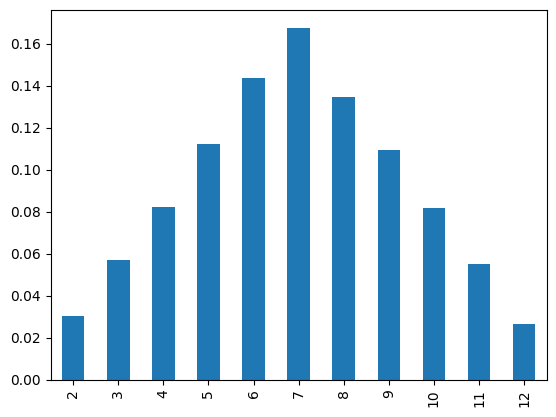

In [ ]:
s.plot(kind='bar')

[]

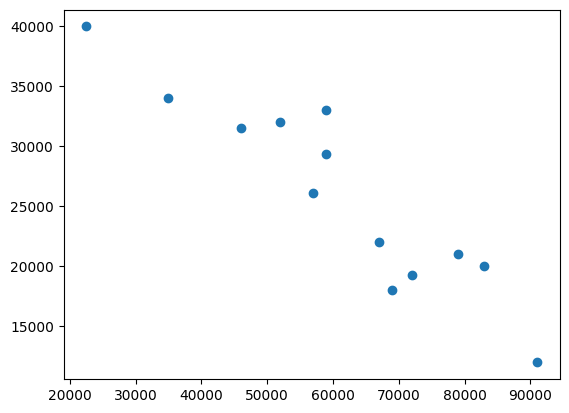

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Mileage'],df['Sell Price'])
plt.plot()

In [ ]:
import pandas as pd
import io
data="""
age,bought_insurance
22,0
25,0
47,1
52,0
46,1
56,1
55,0
60,1
62,1
61,1
18,0
28,0
27,0
29,0
49,1
55,1
25,1
58,1
19,0
18,0
21,0
26,0
40,1
50,1
54,1
23,0
"""
df=pd.read_csv(io.StringIO(data))
df.count()

,0
age,26
bought_insurance,26


[]

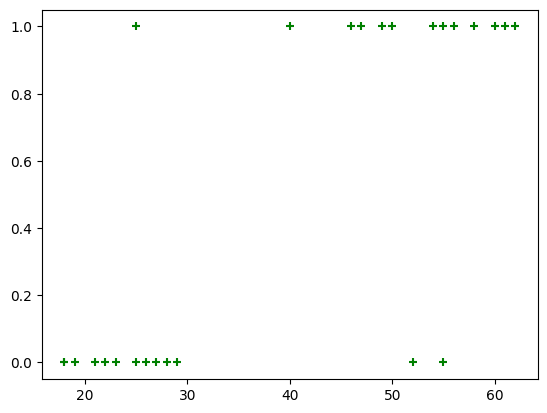

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df.age,df.bought_insurance,marker='+',color='green')
plt.plot()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df[['age']],df['bought_insurance'],test_size=0.1)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
model.score(x_test,y_test)

1.0

In [ ]:
model.predict([[2]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
model.predict_proba(x_test)

array([[0.21423976, 0.78576024],
       [0.81381967, 0.18618033],
       [0.83141051, 0.16858949]])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_digits
digits=load_digits()

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(digits.data,digits.target,test_size=0.3)

In [ ]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9648148148148148

In [ ]:
svm=SVC()
svm.fit(x_train,y_train)
svm.score(x_test,y_test)

0.987037037037037

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
rf.score(x_test,y_test)

0.9740740740740741

In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=3)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
for train_index,test_index in kf.split([1,2,3,4,5,6,7,8,9]):
  print(train_index,test_index)

[3 4 5 6 7 8] [0 1 2]
[0 1 2 6 7 8] [3 4 5]
[0 1 2 3 4 5] [6 7 8]


In [ ]:
def get_score(model,x_test,x_train,y_train,y_test):
  model.fit(x_train,y_train)
  return model.score(x_test,y_test)

In [ ]:
get_score(LogisticRegression(), x_test,x_train,y_train,y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9648148148148148

In [ ]:
get_score(SVC(), x_test,x_train,y_train,y_test)

0.987037037037037

In [ ]:
get_score(RandomForestClassifier(), x_test,x_train,y_train,y_test)

0.975925925925926

In [ ]:
from sklearn.model_selection import StratifiedKFold
folds=StratifiedKFold(n_splits=3)
folds

StratifiedKFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
scores_l=[]
scores_svm=[]
scores_ef=[]

for train_index, test_index in kf.split(digits.data):
  x_train,x_test,y_test,y_train,digits.data[train_index],digits.data[test_index],digits.target[train_index],digits.target[test_index]
  scores_l.append(get_score(LogisticRegression(),x_test,x_train,y_train,y_test))
  scores_svm.append(get_score(SVC(),x_test,x_train,y_train,y_test))
  scores_ef.append(get_score(RandomForestClassifier(n_estimators=40),x_test,x_train,y_train,y_test))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores_l

[0.9648148148148148, 0.9648148148148148, 0.9648148148148148]

In [ ]:
scores_ef

[0.9685185185185186, 0.9685185185185186, 0.9685185185185186]

In [ ]:
scores_svm

[0.987037037037037, 0.987037037037037, 0.987037037037037]

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
cross_val_score(LogisticRegression(),digits.data,digits.target)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

array([0.92222222, 0.86944444, 0.94150418, 0.93871866, 0.89693593])

In [ ]:
cross_val_score(SVC(),digits.data,digits.target)

array([0.96111111, 0.94444444, 0.98328691, 0.98885794, 0.93871866])

In [ ]:
cross_val_score(RandomForestClassifier(),digits.data,digits.target)

array([0.925     , 0.92777778, 0.95821727, 0.95821727, 0.93593315])

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
import numpy as np

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target
model=LogisticRegression()
scores_lr=cross_val_score(model,x,y,cv=5)
print(scores_l)
print(f"Average Accuracy: {scores_lr.mean() * 100:.2f}%")

[0.9648148148148148, 0.9648148148148148, 0.9648148148148148]
Average Accuracy: 97.33%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target
model=SVC()
scores_lr=cross_val_score(model,x,y,cv=5)
print(scores_l)
print(f"Average Accuracy: {scores_lr.mean() * 100:.2f}%")

[0.9648148148148148, 0.9648148148148148, 0.9648148148148148]
Average Accuracy: 96.67%


In [ ]:
iris=load_iris()
x=iris.data
y=iris.target
model=LinearRegression()
scores_lr=cross_val_score(model,x,y,cv=5)
print(scores_l)
print(f"Average Accuracy: {scores_lr.mean() * 100:.2f}%")

[0.9648148148148148, 0.9648148148148148, 0.9648148148148148]
Average Accuracy: 32.26%


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



In [ ]:
iris=load_iris()
x=iris.data
y=iris.target
kf=KFold(n_splits=5, shuffle=True, random_state=42)
model=DecisionTreeClassifier()
fold_number=1
scores=[]
for train_index,test_index in kf.split(x):

   X_train, X_test = X[train_index], X[test_index]
   y_train, y_test = y[train_index], y[test_index]
   model.fit(X_train, y_train)

   # Model Testing
   preds = model.predict(X_test)
   acc = accuracy_score(y_test, preds)
   scores.append(acc)

   print(f"Fold {fold_number} Accuracy: {acc:.4f}")
   fold_number += 1

print(f"\nFinal Mean Accuracy: {np.mean(scores) * 100:.2f}%")



Fold 1 Accuracy: 1.0000
Fold 2 Accuracy: 1.0000
Fold 3 Accuracy: 0.9333
Fold 4 Accuracy: 0.9333
Fold 5 Accuracy: 0.9333

Final Mean Accuracy: 96.00%


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
iris=load_iris()
x=iris.data
y=iris.target
skf=StratifiedKFold(n_splits=5)
model=SVC(kernel='rbf')
scores=cross_val_score(model,x,y,cv=skf)
print(scores)
print(f"average accuracy: {scores.mean()*100:.2f}%")

[0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
average accuracy: 96.67%


In [ ]:
  import pandas as pd
  import io
  data="""
  name,age,income
  rob,27,70000
  micheal,29,90000
  mohen,29,61000
  ismail,28,60000
  kory,42,150000
  gautam,39,155000
  david,41,160000
  andera,38,162000
  brad,36,156000
  angelina,35,130000
  donald,37,137000
  tom,26,45000
  arnold,27,48000
  jared,28,51000
  stark,29,49500
  ranbir,32,53000
  dipika,40,65000
  pariyanka,41,63000
  nick,43,64000
  alia,39,80000
  sid,41,82000
  abdul,39,58000
  """
df=pd.read_csv(io.StringIO(data))
df.head()

,name,age,income
0,rob,27,70000
1,micheal,29,90000
2,mohen,29,61000
3,ismail,28,60000
4,kory,42,150000


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

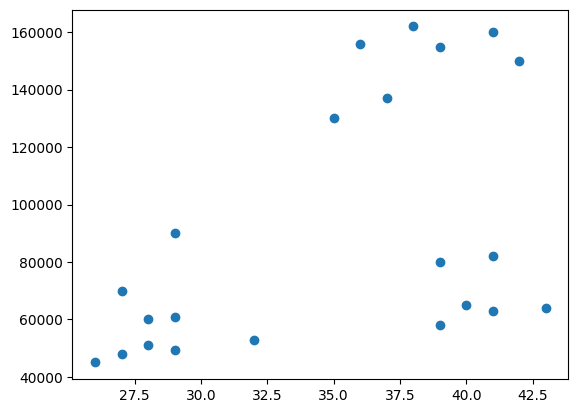

In [ ]:
plt.scatter(df['age'],df['income'])

In [ ]:
km=KMeans(n_clusters=3)
y_predicted=km.fit_predict(df[['age','income']])
y_predicted

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [ ]:
df['cluster']=y_predicted
df.head()

,name,age,income,cluster
0,rob,27,70000,1
1,micheal,29,90000,1
2,mohen,29,61000,1
3,ismail,28,60000,1
4,kory,42,150000,2


Text(0, 0.5, 'income')

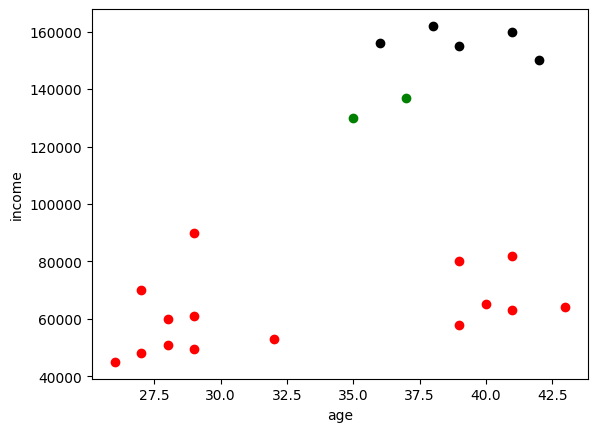

In [ ]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.age,df1['income'],color='green')
plt.scatter(df2.age,df2['income'],color='red')
plt.scatter(df3.age,df3['income'],color='black')
plt.xlabel('age')
plt.ylabel('income')

In [ ]:
scaler=MinMaxScaler()
scaler.fit(df[['income']])
df['income']=scaler.transform(df[['income']])
df

,name,age,income,cluster
0,rob,27,0.213675,1
1,micheal,29,0.384615,1
2,mohen,29,0.136752,1
3,ismail,28,0.128205,1
4,kory,42,0.897436,2
5,gautam,39,0.940171,2
6,david,41,0.982906,2
7,andera,38,1.000000,2
8,brad,36,0.948718,2
9,angelina,35,0.726496,0


In [ ]:
scaler=MinMaxScaler()
scaler.fit(df[['age']])
df['age']=scaler.transform(df[['age']])
df

,name,age,income,cluster
0,rob,0.058824,0.213675,1
1,micheal,0.176471,0.384615,1
2,mohen,0.176471,0.136752,1
3,ismail,0.117647,0.128205,1
4,kory,0.941176,0.897436,2
5,gautam,0.764706,0.940171,2
6,david,0.882353,0.982906,2
7,andera,0.705882,1.000000,2
8,brad,0.588235,0.948718,2
9,angelina,0.529412,0.726496,0


In [ ]:
km=KMeans(n_clusters=3)
z_predicted=km.fit_predict(df[['age','income']])
z_predicted

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [ ]:
df['cluster']=z_predicted
df

,name,age,income,cluster
0,rob,0.058824,0.213675,1
1,micheal,0.176471,0.384615,1
2,mohen,0.176471,0.136752,1
3,ismail,0.117647,0.128205,1
4,kory,0.941176,0.897436,2
5,gautam,0.764706,0.940171,2
6,david,0.882353,0.982906,2
7,andera,0.705882,1.000000,2
8,brad,0.588235,0.948718,2
9,angelina,0.529412,0.726496,2


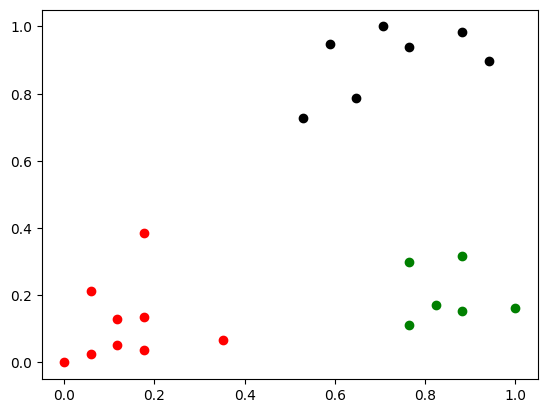

In [ ]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.age,df1['income'],color='green')
plt.scatter(df2.age,df2['income'],color='red')
plt.scatter(df3.age,df3['income'],color='black')

In [ ]:
km.cluster_centers_

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

Text(0, 0.5, 'income')

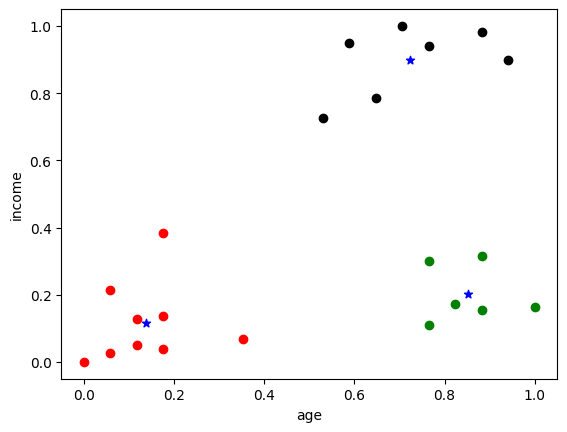

In [ ]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1.age,df1['income'] , color='green')
plt.scatter(df2.age,df2['income'], color='red')
plt.scatter(df3.age,df3['income'], color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='blue',marker='*',label='centroid')
plt.xlabel('age')
plt.ylabel('income')


In [ ]:
k_rng=range(1,10)
sse=[]
for k in k_rng:
  km=KMeans(n_clusters=k)
  km.fit(df[['age','income']])
  sse.append(km.inertia_)

In [ ]:
sse

[5.434011511988179,
 2.3456144914725936,
 0.4750783498553097,
 0.3687734076440591,
 0.2818479744366238,
 0.2692957941449647,
 0.18279994469329933,
 0.1327661931978319,
 0.11631891441136413]

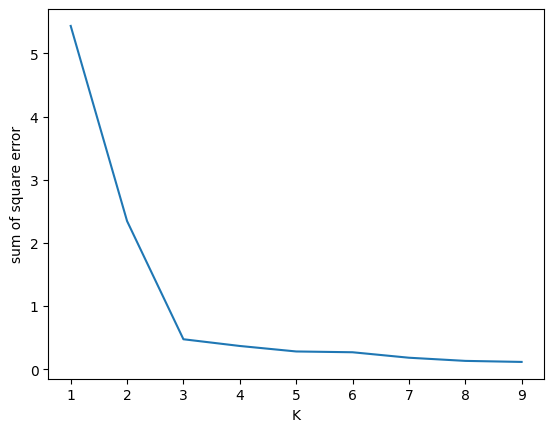

In [ ]:
plt.xlabel('K')
plt.ylabel('sum of square error')
plt.plot(k_rng,sse)

In [ ]:
import pandas as pd

# Open direct raw CSV endpoint
raw_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Load directly into DataFrame
df = pd.read_csv(raw_url)

# Save to local CSV file
df.to_csv("titanic.csv", index=False)
print("Saved to titanic.csv!")
print(df.head())

Saved to titanic.csv!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

In [ ]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
for idx, col in enumerate(df.columns):
    print(f"Index {idx}: {col}")

Index 0: PassengerId
Index 1: Survived
Index 2: Pclass
Index 3: Name
Index 4: Sex
Index 5: Age
Index 6: SibSp
Index 7: Parch
Index 8: Ticket
Index 9: Fare
Index 10: Cabin
Index 11: Embarked


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns', inplace=True)
df.head()


,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [ ]:
dummies=pd.get_dummies(df['Sex'],dtype=int)
dummies.head(5)

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1


In [ ]:
target=df.Survived
inputs=df.drop('Survived',axis='columns')

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [ ]:
inputs=pd.concat([inputs,dummies],axis='columns')
inputs.head(3)


,Pclass,Sex,Age,Fare,female,male
0,3,male,22.0,7.2500,0,1
1,1,female,38.0,71.2833,1,0
2,3,female,26.0,7.9250,1,0


In [ ]:
inputs.drop('Sex',axis='columns',inplace=True)
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,0,1
1,1,38.0,71.2833,1,0
2,3,26.0,7.9250,1,0
3,1,35.0,53.1000,1,0
4,3,35.0,8.0500,0,1


In [ ]:
u=inputs['Age'].isna().sum()
print(u)

177


In [ ]:
null_percentage = inputs['Age'].isna().mean() * 100
print(f"{null_percentage:.2f}%")

19.87%


In [ ]:
inputs['Age']= inputs.Age.fillna(inputs.Age.mean())
inputs.head()

,Pclass,Age,Fare,female,male
0,3,22.0,7.2500,0,1
1,1,38.0,71.2833,1,0
2,3,26.0,7.9250,1,0
3,1,35.0,53.1000,1,0
4,3,35.0,8.0500,0,1


In [ ]:
inputs.Age.isna().sum()

np.int64(0)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(inputs,target,test_size=0.3)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()

In [ ]:
model.fit(x_train,y_train)

GaussianNB()

In [ ]:
model.score(x_test,y_test)

0.8208955223880597

In [ ]:
model.predict_proba(x_test[:10])

array([[0.98490021, 0.01509979],
       [0.03534046, 0.96465954],
       [0.02163243, 0.97836757],
       [0.98719288, 0.01280712],
       [0.98678188, 0.01321812],
       [0.07627326, 0.92372674],
       [0.0376568 , 0.9623432 ],
       [0.98645813, 0.01354187],
       [0.07141381, 0.92858619],
       [0.98708769, 0.01291231]])

In [ ]:
  !pip install kagglehub pandas

In [ ]:
import os
import kagglehub
import pandas as pd

# Download dataset (automatically caches and returns local folder path)
path = kagglehub.dataset_download("abdmental01/email-spam-dedection")

# Locate and load the CSV file from the downloaded path
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(df.head())

100%|██████████| 208k/208k [00:00<00:00, 745kB/s]

Extracting files...
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [ ]:
spam=(df['Category']=='ham').mean()*100
print(f"spam percentage : {spam:.2f}%" )


spam percentage : 86.59%


In [ ]:
df['spam']=df['Category'].apply(lambda x: 1 if x=="spam" else 0)
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.Message,df.spam,test_size=0.25)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
y=CountVectorizer()
x_train_count=y.fit_transform(x_train.values)
x_train_count.toarray()[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train_count,y_train)

MultinomialNB()

In [ ]:
emails=[
    'hey mohan, can we get together to watch football game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]
emails_count=y.transform(emails)
model.predict(emails_count)


array([0, 1])

In [ ]:
model.score(x_train_count,y_train)
x=round(model.score(x_train_count,y_train),2)*100
print(f'accuracy percentage:{x}%')

accuracy percentage:99.0%


In [ ]:
from sklearn.pipeline import Pipeline
clf=Pipeline([
    ('vectorizer',CountVectorizer()),
    ('nb',MultinomialNB())
])


In [ ]:
clf.fit(x_train,y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [ ]:
clf.score(x_test,y_test)

0.9863603732950467

**Wine dataset**


In [ ]:
from sklearn import datasets
wine = datasets.load_wine()
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [70]:
wine.data[0:2]
wine.feature_names
wine.target_names
wine.target[0:2]
import pandas as pd
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [71]:
df['Target']=wine.target
df[50:70]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
50,13.05,1.73,2.04,12.4,92.0,2.72,3.27,0.17,2.91,7.20,1.12,2.91,1150.0,0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0,0
52,13.82,1.75,2.42,14.0,111.0,3.88,3.74,0.32,1.87,7.05,1.01,3.26,1190.0,0
53,13.77,1.90,2.68,17.1,115.0,3.00,2.79,0.39,1.68,6.30,1.13,2.93,1375.0,0
54,13.74,1.67,2.25,16.4,118.0,2.60,2.90,0.21,1.62,5.85,0.92,3.20,1060.0,0
55,13.56,1.73,2.46,20.5,116.0,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120.0,0
56,14.22,1.70,2.30,16.3,118.0,3.20,3.00,0.26,2.03,6.38,0.94,3.31,970.0,0
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
58,13.72,1.43,2.50,16.7,108.0,3.40,3.67,0.19,2.04,6.80,0.89,2.87,1285.0,0
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1


In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(wine.data,wine.target,test_size=0.3,random_state=100)

In [74]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
model = GaussianNB()
model.fit(x_train,y_train)

GaussianNB()

In [75]:
model.predict(x_test[0:5])

array([1, 2, 0, 1, 2])

In [76]:
model.score(x_test,y_test)

1.0

In [77]:
model=MultinomialNB()
model.fit(x_train,y_train)


MultinomialNB()

In [78]:
model.predict(x_test[0:5])

array([2, 2, 0, 0, 2])

In [79]:
model.score(x_test,y_test)

0.7777777777777778

**iris dataset for hyperparameter tunning**


In [107]:
from sklearn import svm,datasets
iris=datasets.load_iris()

In [108]:
import pandas as pd
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['flower']=iris.target
df['flower']=df['flower'].apply(lambda x: iris.target_names[x])
df[47:52]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
47,4.6,3.2,1.4,0.2,setosa
48,5.3,3.7,1.5,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor


In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(iris.data,iris.target,test_size=0.3,random_state=100)

In [110]:
  model=svm.SVC(kernel='rbf',C=30,gamma='auto')
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9777777777777777

In [111]:
from sklearn.model_selection import cross_val_score

In [126]:
cross_val_score(svm.SVC(kernel='linear',C=10,gamma='auto'),iris.data,iris.target,cv=5)

array([1.        , 1.        , 0.9       , 0.96666667, 1.        ])

In [113]:
cross_val_score(svm.SVC(kernel='rbf',C=10,gamma='auto'),iris.data,iris.target,cv=5)

array([0.96666667, 1.        , 0.96666667, 0.96666667, 1.        ])

In [114]:
cross_val_score(svm.SVC(kernel='rbf',C=20,gamma='auto'),iris.data,iris.target,cv=5)

array([0.96666667, 1.        , 0.9       , 0.96666667, 1.        ])

In [120]:
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(svm.SVC(gamma='auto'),{
    'C':[1,10,20],
    'kernel':['rbf','linear']
},cv=5,return_train_score=False)
clf.fit(iris.data,iris.target)
clf.cv_results_

{'mean_fit_time': array([0.00216751, 0.001826  , 0.00178633, 0.00169206, 0.00187182,
        0.001682  ]),
 'std_fit_time': array([2.22398987e-04, 1.42323902e-04, 5.70097860e-05, 3.47878770e-05,
        3.81267017e-05, 1.21724245e-04]),
 'mean_score_time': array([0.00160255, 0.00128393, 0.00130196, 0.00132256, 0.00131497,
        0.00125713]),
 'std_score_time': array([2.98668301e-04, 5.76985572e-05, 6.52384684e-05, 3.15356319e-05,
        8.72189258e-05, 5.78844566e-05]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C': 1, 'kernel': 'linear'},
  {'C': 10, 'kernel': 'rbf'},
  {'C': 10, 'kernel': 'linear'},
  {'C': 20, 'kernel': 'rbf'},
 

In [125]:
df=pd.DataFrame(clf.cv_results_)
df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002168,0.000222,0.001603,0.000299,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.001826,0.000142,0.001284,0.000058,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
2,0.001786,0.000057,0.001302,0.000065,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
3,0.001692,0.000035,0.001323,0.000032,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,4
4,0.001872,0.000038,0.001315,0.000087,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.966667,1.0,0.966667,0.036515,5
5,0.001682,0.000122,0.001257,0.000058,20,linear,"{'C': 20, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.933333,1.0,0.966667,0.042164,6


In [123]:
df[['param_C','param_kernel','mean_test_score']]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.980000
1,1,linear,0.980000
2,10,rbf,0.980000
3,10,linear,0.973333
4,20,rbf,0.966667
5,20,linear,0.966667


In [130]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [148]:
from sklearn import datasets
digits=datasets.load_digits()

In [150]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [151]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto'),
        'params' : {
            'C': [1,10,20],
            'kernel': ['rbf','linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'params': {
            'C': [1,5,10]
        }
    },
    'naive_bayes_gaussian': {
        'model': GaussianNB(),
        'params': {}
    },
    'naive_bayes_multinomial': {
        'model': MultinomialNB(),
        'params': {}
    },
    'decision_tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini','entropy'],

        }
    }
}

In [152]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
scores=[]
for model_name, mp in model_params.items():
    clf =  GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(digits.data, digits.target)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })

df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,model,best_score,best_params
0,svm,0.947697,"{'C': 1, 'kernel': 'linear'}"
1,random_forest,0.900952,{'n_estimators': 10}
2,logistic_regression,0.922114,{'C': 1}
3,naive_bayes_gaussian,0.806928,{}
4,naive_bayes_multinomial,0.870350,{}
5,decision_tree,0.814712,{'criterion': 'entropy'}
